# BNJetTag results summary

A rerunnable summary of what the project has measured so far, laid out for screenshots onto
slides. Each run regenerates every table and figure from saved data: prediction arrays are
scored again, synthesis reports and pod logs are parsed again, and no number is typed in by
hand.

**How to read the labels.** Every number names its metric (macro one-vs-rest AUC or top-1
accuracy), its split and its size n, and carries one of four statuses.

- **verified**: recomputed here from saved prediction arrays (for the pT study, also checked in its VERIFY.md);
- **reported**: read from a saved evaluation record whose arrays are not on this machine, so it is quoted, not recomputed;
- **telemetry**: read from saved pod logs of runs that are still going; not a result;
- **archived**: Round 14, the pre-conference fixed-precision study with no EBOP target, shown only in its own labelled sections.

*Held-out* (ROC-test) is the dataset's separate archive of jets that neither training nor checkpoint selection ever sees.
*Validation* is an internal split of the training archive, used to pick checkpoints. The two
never share a column. Current work is EBOP-constrained: lower EBOPs is cheaper, and a result
counts only at or under its target.

Rerun from the repository root (about a minute on this laptop):
`.venv-hgq2/bin/python -m nbconvert --to notebook --execute --inplace messages/2026-09-29-results-notebook/results_summary.ipynb`

In [1]:
import time
T0 = time.time()
from IPython.display import Image, Markdown, display
import numpy as np
import nbhelpers as H

H.apply_style()


def md(text):
    display(Markdown(text))


def show(png, caption):
    display(Image(filename=str(png), width=960))
    md(caption)


md(f"Executed {time.strftime('%Y-%m-%d %H:%M %Z')}. Each figure is also saved as PNG and SVG in "
   f"`{H.FIG_DIR.relative_to(H.REPO)}/`, ready for a slide without a screenshot.")

Executed 2026-09-29 07:55 PDT. Each figure is also saved as PNG and SVG in `messages/2026-09-29-results-notebook/figures/`, ready for a slide without a screenshot.

## 1. Headline: the best verified current results

These are the EBOP-constrained ablation runs: each arm's checkpoint is the one with the best
validation AUC among those at or under the EBOP target. The table is sorted by held-out AUC.

In [2]:
cur = H.load_current()
rows = sorted([r for r in cur["rows"] if not r["missing"]], key=lambda r: -r["test_auc"])
B, NT, NV = cur["budget"], cur["n_test"], cur["n_val"]
md(f"**Current era, EBOP-constrained, N = {cur['n_part']}** (inputs {', '.join(cur['features'])}), binary weights, "
   f"target {B:,} EBOPs, one seed per arm (seed 1): single runs, no interval. Held-out (ROC-test) = jets never used in training "
   f"or checkpoint selection, n = {NT:,}; validation = {cur['val_split']}, n = {NV:,}. **Status: verified**, recomputed here from the saved "
   f"logits (softmax, then one AUC per class); EBOPs remeasured from each checkpoint.")
tab = [[r["name"], f"{r['ebops']:,}", "yes" if r["ebops"] <= B else "**no**", f"**{r['test_auc']:.4f}**",
        H.pct(r["test_acc"]), f"{r['val_auc']:.4f}", H.pct(r["val_acc"]), f"{r['epochs']:,} / {r['sel_epoch']:,}"]
       for r in rows]
md(H.md_table(["arm", "EBOPs of the checkpoint", f"at or under {B:,}?", f"held-out (ROC-test) macro-OvR AUC (n = {NT:,})",
               f"held-out (ROC-test) top-1 accuracy (n = {NT:,})", f"validation macro-OvR AUC (n = {NV:,})",
               f"validation top-1 accuracy (n = {NV:,})", "epochs run / selected epoch"], tab))
missing = [r["name"] for r in cur["rows"] if r["missing"]]
if missing:
    md("No saved arrays match the stored checkpoint for: " + ", ".join(missing) + ". Those arms are left out.")
best_auc, best_acc = rows[0], max(rows, key=lambda r: r["test_acc"])
spread = rows[0]["test_auc"] - rows[-1]["test_auc"]
md(f"Highest held-out macro-OvR AUC: **{best_auc['name']}**, {best_auc['test_auc']:.4f} at {best_auc['ebops']:,} EBOPs. "
   f"Highest held-out top-1 accuracy: **{best_acc['name']}**, {H.pct(best_acc['test_acc'])} at {best_acc['ebops']:,} EBOPs. "
   f"The {len(rows)} arms span {spread:.4f} in held-out AUC, but each is a single seed, so no difference between two arms "
   f"is resolved: the order is a record, not a ranking.")

**Current era, EBOP-constrained, N = 8** (inputs pt, etarel, phirel), binary weights, target 350,000 EBOPs, one seed per arm (seed 1): single runs, no interval. Held-out (ROC-test) = jets never used in training or checkpoint selection, n = 260,000; validation = 20% of Zenodo training archive, n = 124,000. **Status: verified**, recomputed here from the saved logits (softmax, then one AUC per class); EBOPs remeasured from each checkpoint.

| arm | EBOPs of the checkpoint | at or under 350,000? | held-out (ROC-test) macro-OvR AUC (n = 260,000) | held-out (ROC-test) top-1 accuracy (n = 260,000) | validation macro-OvR AUC (n = 124,000) | validation top-1 accuracy (n = 124,000) | epochs run / selected epoch |
|---|---|---|---|---|---|---|---|
| Reduced feed-forward width | 329,838 | yes | **0.8535** | 58.31 % | 0.8545 | 58.52 % | 1,000 / 726 |
| Channel-wise quantization | 317,890 | yes | **0.8508** | 58.74 % | 0.8518 | 58.89 % | 1,000 / 999 |
| Gradual budget schedule | 349,550 | yes | **0.8469** | 57.51 % | 0.8477 | 57.80 % | 1,000 / 960 |
| 8-bit attention probabilities | 340,174 | yes | **0.8454** | 57.34 % | 0.8463 | 57.62 % | 1,000 / 593 |
| Tensor-wise quantization (baseline) | 348,526 | yes | **0.8445** | 57.48 % | 0.8453 | 57.67 % | 1,000 / 894 |
| Knowledge distillation (selected from an interim snapshot at epoch 898 of 1,000) | 348,366 | yes | **0.8413** | 56.91 % | 0.8420 | 57.12 % | 898 / 184 |
| Fixed-width recovery | 349,390 | yes | **0.8407** | 56.94 % | 0.8410 | 57.04 % | 1,000 / 205 |

Highest held-out macro-OvR AUC: **Reduced feed-forward width**, 0.8535 at 329,838 EBOPs. Highest held-out top-1 accuracy: **Channel-wise quantization**, 58.74 % at 317,890 EBOPs. The 7 arms span 0.0128 in held-out AUC, but each is a single seed, so no difference between two arms is resolved: the order is a record, not a ranking.

In [3]:
chk = [[r["name"], f"{r['claim_test_auc']:.6f}", f"{r['test_auc']:.6f}", f"{r['test_auc'] - r['claim_test_auc']:+.1e}",
        f"{r['claim_test_acc']:.6f}", f"{r['test_acc']:.6f}", f"{r['test_acc'] - r['claim_test_acc']:+.1e}",
        f"{r['claim_val_auc']:.6f}", f"{r['val_auc']:.6f}", f"{r['val_auc'] - r['claim_val_auc']:+.1e}"] for r in rows]
md(f"**Check against the stored record** (`{H.ABL_JSON}`, evaluated {cur['eval_date']}): stored value, value "
   "recomputed here, difference. The stored validation AUC is the selection-time value logged in training; a fresh "
   "recompute differs from it slightly, and the last column shows by how much. Held-out values must agree exactly.")
md(H.md_table(["arm", f"held-out AUC stored", "recomputed", "Δ", f"held-out accuracy stored", "recomputed", "Δ",
               f"validation AUC stored (selection)", "recomputed", "Δ"], chk))
worst = max(abs(r["test_auc"] - r["claim_test_auc"]) for r in rows)
md(f"Largest held-out AUC disagreement: {worst:.1e}.")

**Check against the stored record** (`publication/results/post_conference/ablation_metrics.json`, evaluated 2026-09-16): stored value, value recomputed here, difference. The stored validation AUC is the selection-time value logged in training; a fresh recompute differs from it slightly, and the last column shows by how much. Held-out values must agree exactly.

| arm | held-out AUC stored | recomputed | Δ | held-out accuracy stored | recomputed | Δ | validation AUC stored (selection) | recomputed | Δ |
|---|---|---|---|---|---|---|---|---|---|
| Reduced feed-forward width | 0.853526 | 0.853526 | +0.0e+00 | 0.583131 | 0.583131 | +0.0e+00 | 0.854457 | 0.854452 | -5.2e-06 |
| Channel-wise quantization | 0.850795 | 0.850795 | +0.0e+00 | 0.587431 | 0.587431 | +0.0e+00 | 0.851884 | 0.851802 | -8.2e-05 |
| Gradual budget schedule | 0.846941 | 0.846941 | +0.0e+00 | 0.575085 | 0.575085 | +0.0e+00 | 0.847682 | 0.847678 | -3.9e-06 |
| 8-bit attention probabilities | 0.845380 | 0.845380 | +0.0e+00 | 0.573435 | 0.573435 | +0.0e+00 | 0.846262 | 0.846262 | +3.8e-08 |
| Tensor-wise quantization (baseline) | 0.844527 | 0.844527 | +0.0e+00 | 0.574758 | 0.574758 | +0.0e+00 | 0.845267 | 0.845266 | -2.9e-07 |
| Knowledge distillation (selected from an interim snapshot at epoch 898 of 1,000) | 0.841338 | 0.841338 | +0.0e+00 | 0.569123 | 0.569123 | +0.0e+00 | 0.841975 | 0.841979 | +3.9e-06 |
| Fixed-width recovery | 0.840727 | 0.840727 | +0.0e+00 | 0.569404 | 0.569404 | +0.0e+00 | 0.841019 | 0.841019 | -3.7e-09 |

Largest held-out AUC disagreement: 0.0e+00.

In [4]:
conf = H.load_confirmation_reported()
c0 = conf["rows"][0]
md("**Reported, not verified here.** The confirmation campaign's evaluation job scored two architecture-batch "
   "checkpoints on the same held-out split. Only its JSON record is saved on this machine (no prediction arrays), so "
   "these numbers are quoted from it, not recomputed. Seed 1, single run, no interval.")
tab = [[r["arm"], f"{r['ebops']:,}", "yes" if r["ebops"] <= B else f"**no**, above the N = {cur['n_part']} target",
        f"{r['ho_auc']:.4f}", H.pct(r["ho_acc"]), f"{r['va_auc']:.4f}", H.pct(r["va_acc"])] for r in conf["rows"]]
md(H.md_table(["checkpoint", "EBOPs", f"at or under {B:,}?", f"held-out (ROC-test) macro-OvR AUC (n = {c0['n_ho']:,})",
               f"held-out (ROC-test) top-1 accuracy (n = {c0['n_ho']:,})", f"validation macro-OvR AUC (n = {c0['n_va']:,})",
               f"validation top-1 accuracy (n = {c0['n_va']:,})"], tab))
md(f"Status: reported, from `{H.CONF_EVAL}` (job `{conf['job']}`; scope: {conf['scope']}).")

head = H.load_head_refit(cur["y_test"])
md(f"**Frozen-backbone follow-up (verified, mixed precision).** The channel-wise checkpoint with its final layer refit at "
   f"{head['bits']} bits and every other layer unchanged: held-out macro-OvR AUC {head['auc']:.4f} and top-1 accuracy "
   f"{H.pct(head['acc'])} (n = {head['n']:,}) at {head['ebops']:,} EBOPs, against {head['base_auc']:.4f} and "
   f"{H.pct(head['base_acc'])} at {head['base_ebops']:,} EBOPs for the checkpoint it starts from. The accuracy gain is "
   f"{100 * head['d_acc']:+.2f} pp with an event-level paired 95 % interval of [{100 * head['lo']:+.2f}, "
   f"{100 * head['hi']:+.2f}] pp (stored record: [{100 * head['claim_ci'][0]:+.2f}, {100 * head['claim_ci'][1]:+.2f}] pp). "
   "That interval covers the jets only: there is one training seed, so the seed-to-seed spread is unknown. The final "
   "layer is no longer binary, and no hardware was measured.")

**Reported, not verified here.** The confirmation campaign's evaluation job scored two architecture-batch checkpoints on the same held-out split. Only its JSON record is saved on this machine (no prediction arrays), so these numbers are quoted from it, not recomputed. Seed 1, single run, no interval.

| checkpoint | EBOPs | at or under 350,000? | held-out (ROC-test) macro-OvR AUC (n = 260,000) | held-out (ROC-test) top-1 accuracy (n = 260,000) | validation macro-OvR AUC (n = 124,000) | validation top-1 accuracy (n = 124,000) |
|---|---|---|---|---|---|---|
| batch20260917-a02-s1 | 349,298 | yes | 0.8604 | 60.78 % | 0.8612 | 61.08 % |
| batch20260917-a11-s1 | 479,462 | **no**, above the N = 8 target | 0.8738 | 62.33 % | 0.8749 | 62.62 % |

Status: reported, from `campaigns/2026-09-23-confirmation/evaluation-results.json` (job `kai-confirm-eval-a02-a11-0923-r4`; scope: deterministic checkpoint evaluation copied from completed cluster job log).

**Frozen-backbone follow-up (verified, mixed precision).** The channel-wise checkpoint with its final layer refit at 8 bits and every other layer unchanged: held-out macro-OvR AUC 0.8560 and top-1 accuracy 59.14 % (n = 260,000) at 322,510 EBOPs, against 0.8508 and 58.74 % at 317,890 EBOPs for the checkpoint it starts from. The accuracy gain is +0.40 pp with an event-level paired 95 % interval of [+0.32, +0.47] pp (stored record: [+0.32, +0.47] pp). That interval covers the jets only: there is one training seed, so the seed-to-seed spread is unknown. The final layer is no longer binary, and no hardware was measured.

## 2. Current era: cost against performance, and the ROC curves

The same seven arms as the headline table, drawn against their EBOPs, then the ROC curves of
the arm with the highest held-out AUC in the HEP convention (mistag rate on a log axis).

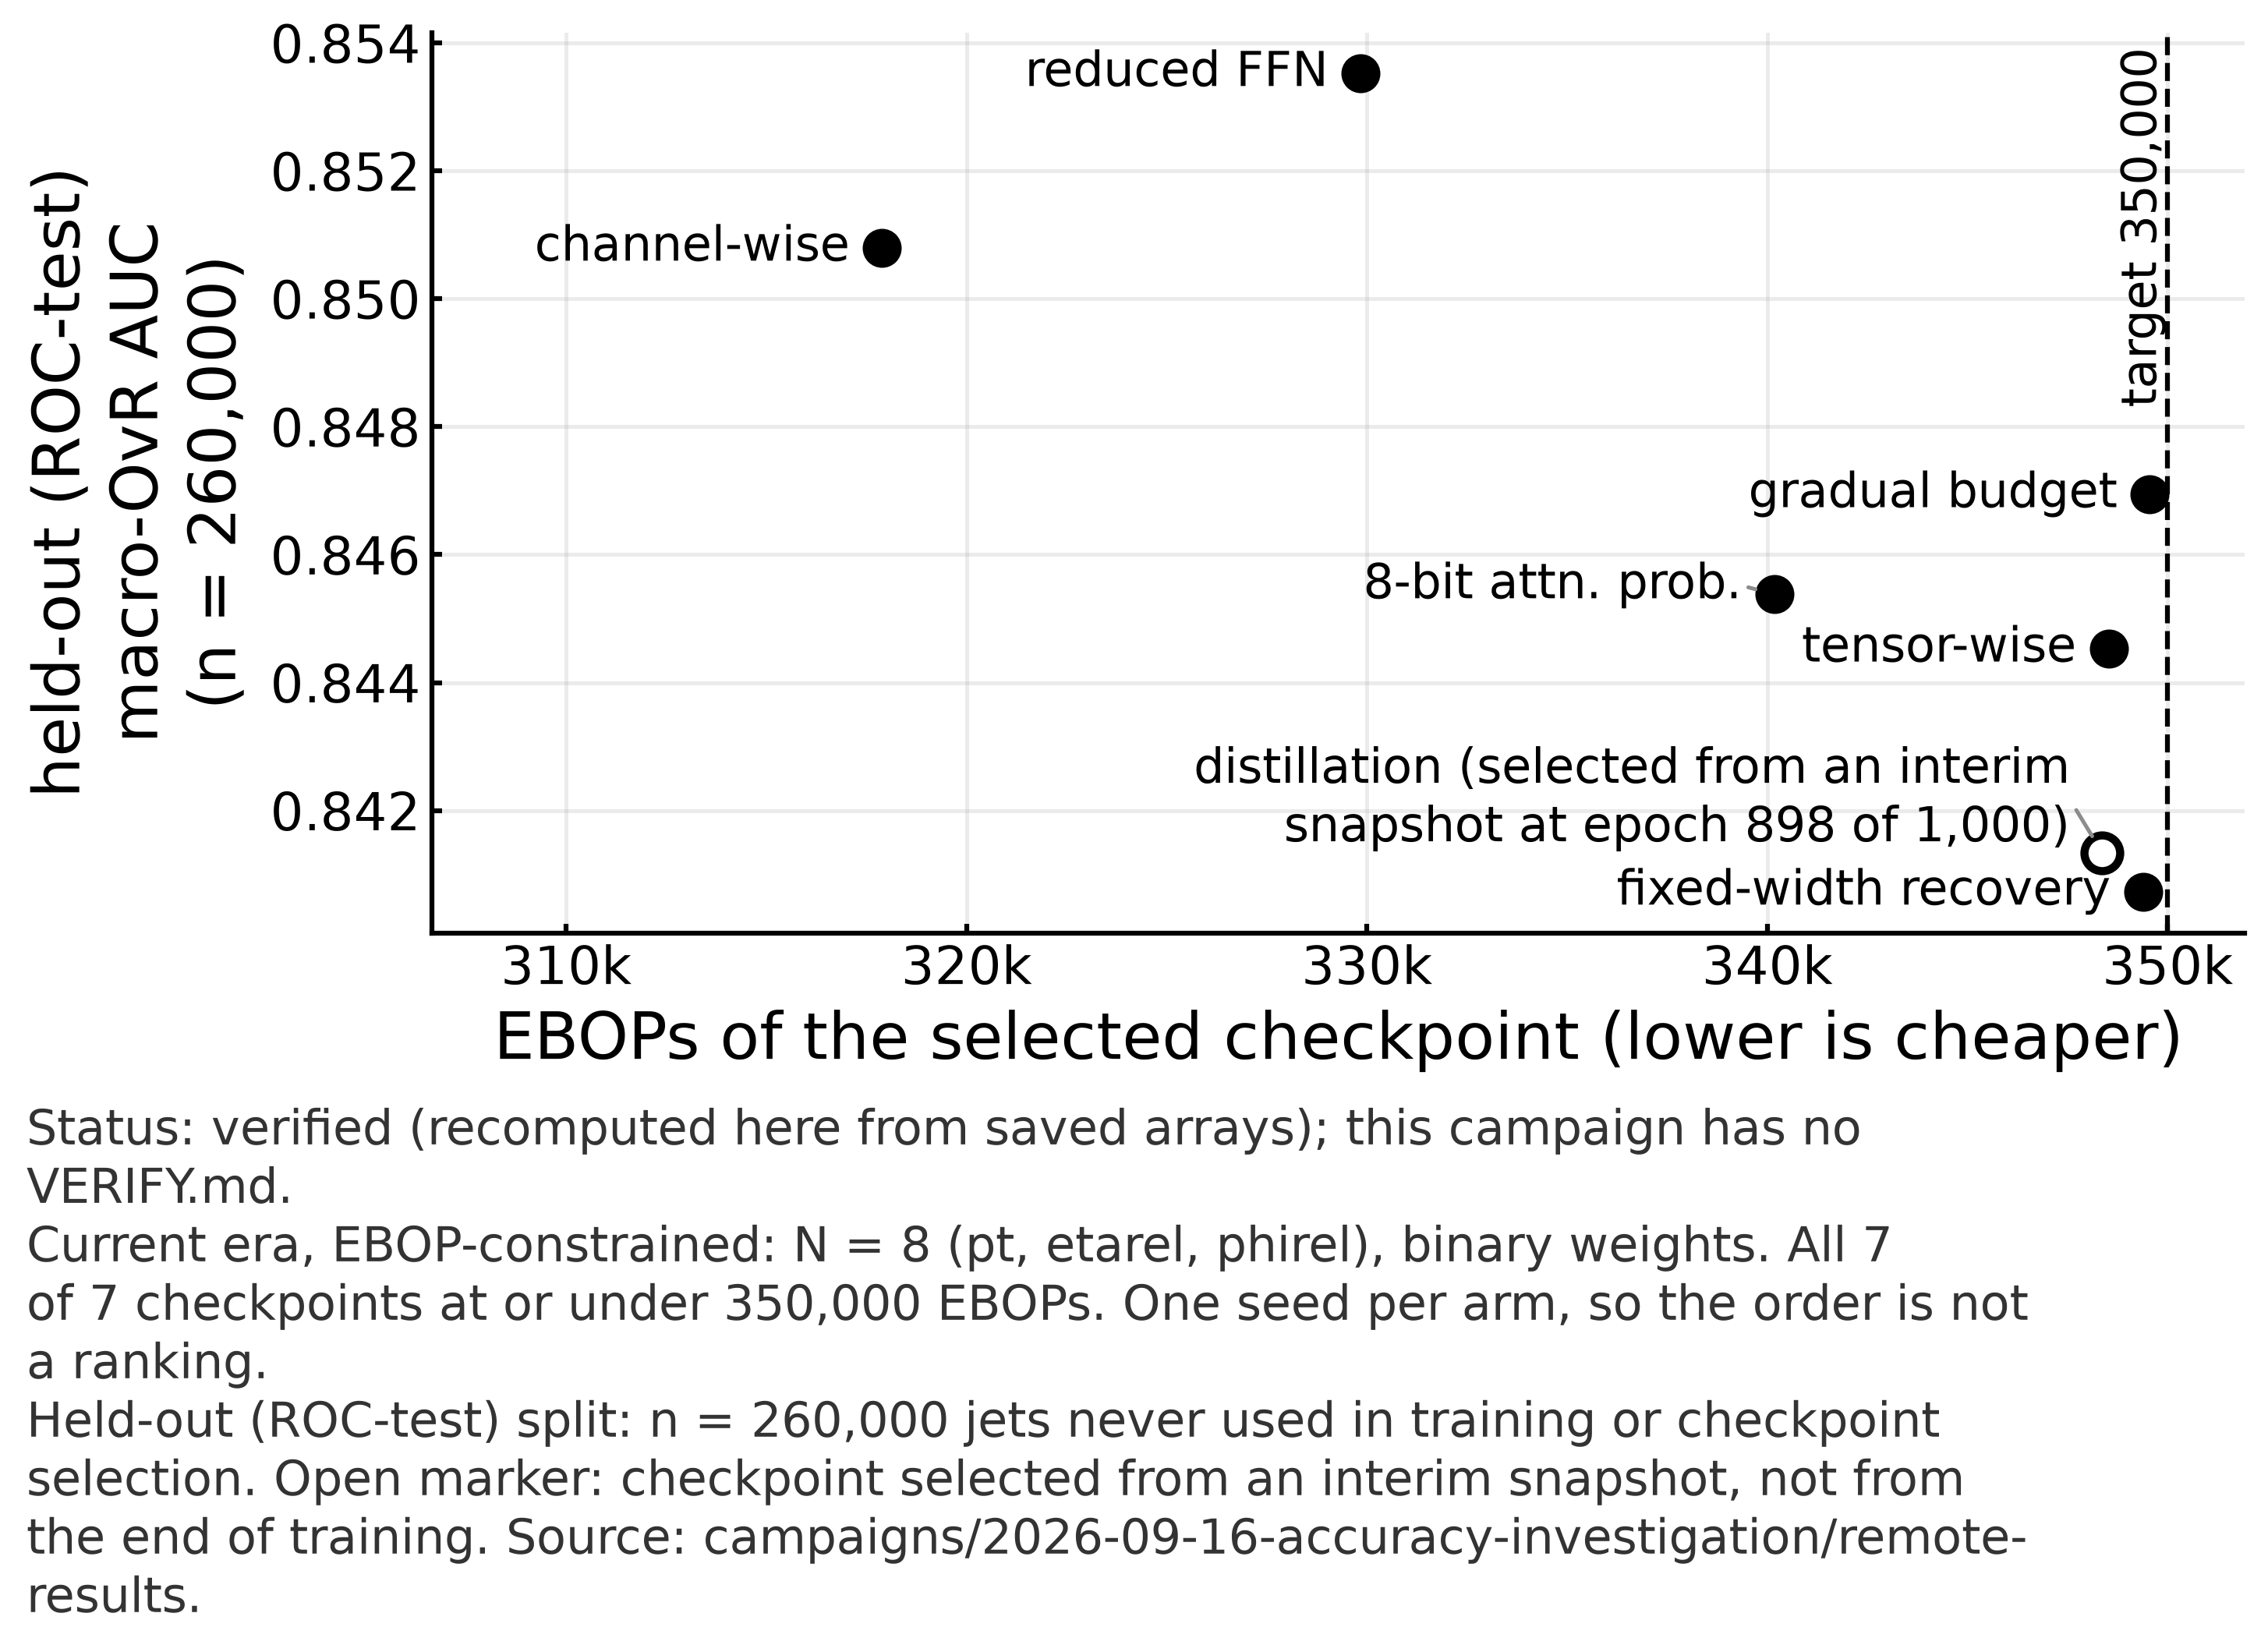

**Figure 1.** Held-out macro-OvR AUC (n = 260,000) against the EBOPs of each selected checkpoint, for the 7 EBOP-constrained N = 8 arms. 7 of 7 sit at or under the 350,000 target (dashed), between 317,890 and 349,550 EBOPs. They span 0.0128 in AUC with one seed each, so the vertical order is not an established ranking. The open marker is Knowledge distillation (selected from an interim snapshot at epoch 898 of 1,000).

In [5]:
n_under = sum(r["ebops"] <= B for r in rows)
lo_e, hi_e = min(r["ebops"] for r in rows), max(r["ebops"] for r in rows)
png = H.fig_current_vs_ebops(cur, "auc")
show(png, f"**Figure 1.** Held-out macro-OvR AUC (n = {NT:,}) against the EBOPs of each selected checkpoint, for the "
          f"{len(rows)} EBOP-constrained N = {cur['n_part']} arms. {n_under} of {len(rows)} sit at or under the {B:,} "
          f"target (dashed), between {lo_e:,} and {hi_e:,} EBOPs. They span {spread:.4f} in AUC with one seed each, "
          f"so the vertical order is not an established ranking."
          + "".join(f" The open marker is {r['name']}." for r in rows if r["interim"]))

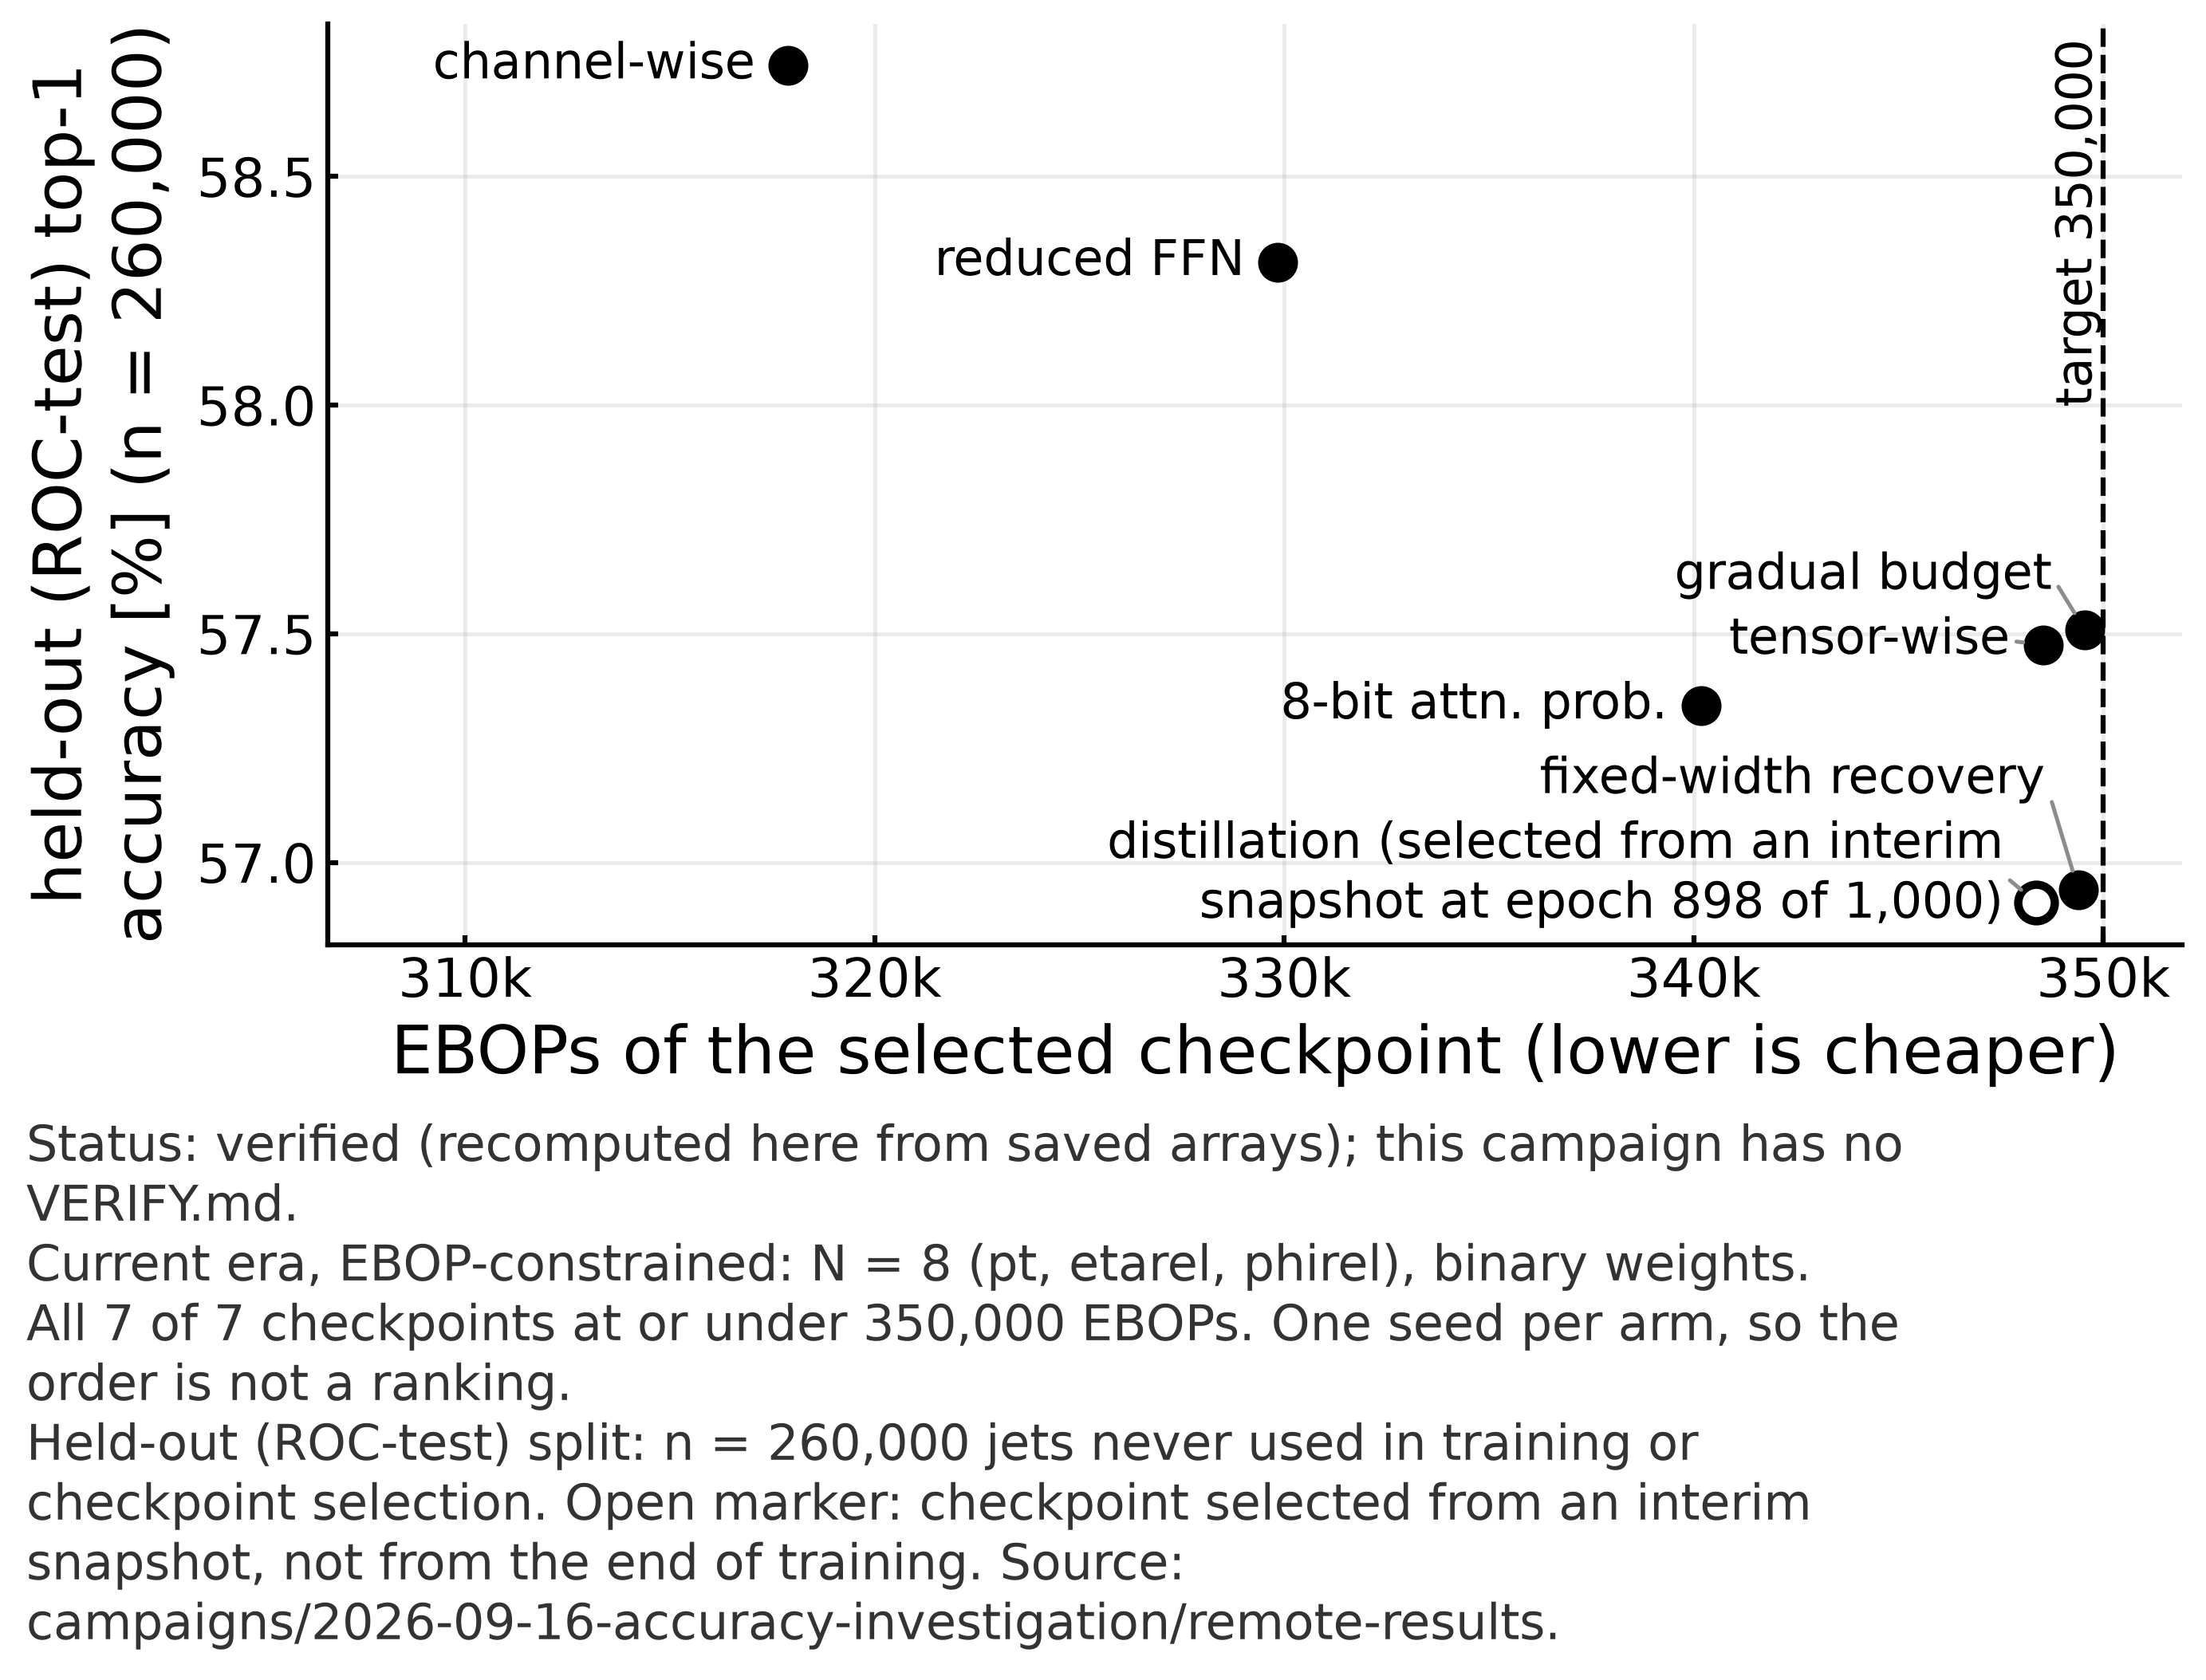

**Figure 2.** Held-out top-1 accuracy (n = 260,000) for the same arms and EBOPs. The arms span 1.83 pp, again one seed each. AUC and accuracy pick different arms (reduced FFN for AUC, channel-wise for accuracy): AUC ranks scores within each class, accuracy asks whether the right class wins outright.

In [6]:
acc_spread = max(r["test_acc"] for r in rows) - min(r["test_acc"] for r in rows)
png = H.fig_current_vs_ebops(cur, "acc")
same = best_auc["arm"] == best_acc["arm"]
show(png, f"**Figure 2.** Held-out top-1 accuracy (n = {NT:,}) for the same arms and EBOPs. The arms span "
          f"{100 * acc_spread:.2f} pp, again one seed each. "
          + ("AUC and accuracy pick the same arm." if same else
             f"AUC and accuracy pick different arms ({best_auc['short']} for AUC, {best_acc['short']} for accuracy): "
             "AUC ranks scores within each class, accuracy asks whether the right class wins outright."))

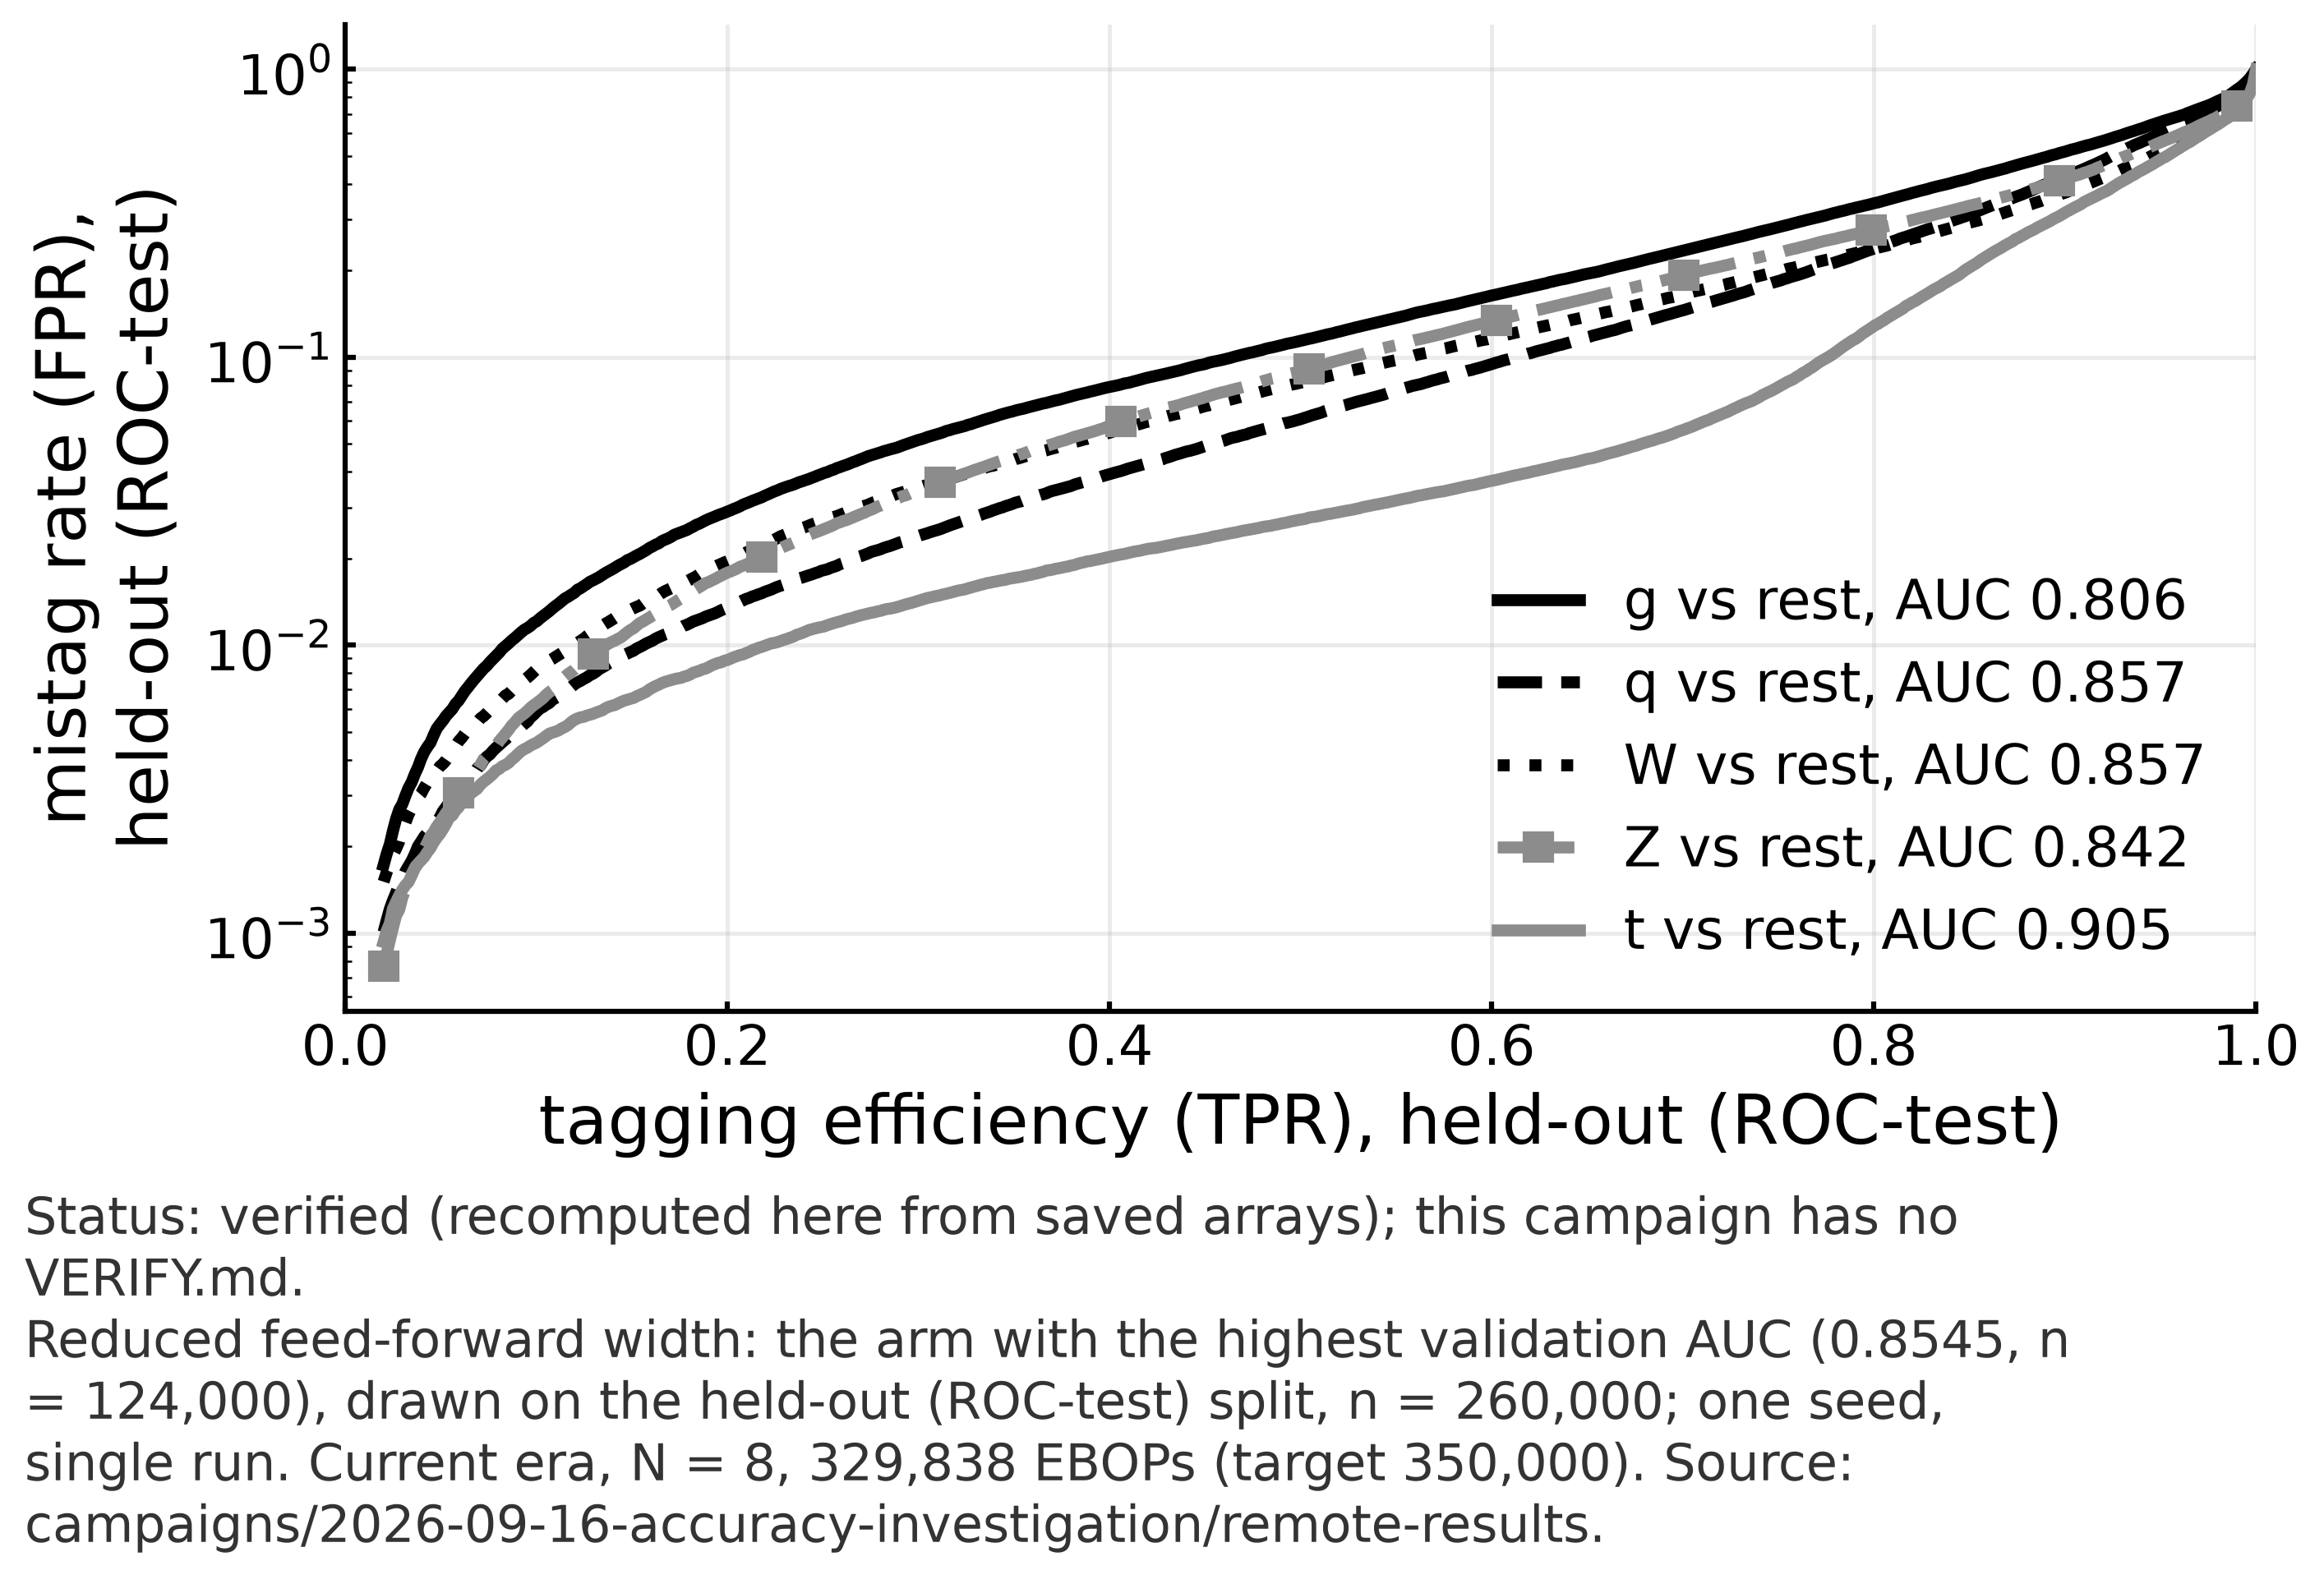

**Figure 3.** One-vs-rest ROC curves for Reduced feed-forward width, the arm with the highest validation AUC (0.8545, n = 124,000), drawn on the held-out (ROC-test) split (macro-OvR AUC 0.8535, n = 260,000, seed 1), mistag rate on a log y axis. t vs rest is the easiest class (AUC 0.905) and g vs rest the hardest (0.806). Single run: the curves carry no uncertainty band.

In [7]:
best_val = max(rows, key=lambda r: r["val_auc"])
png = H.fig_current_roc(cur, best_val)
cls = best_val["test_cls"]
easy, hard = int(np.argmax(cls)), int(np.argmin(cls))
show(png, f"**Figure 3.** One-vs-rest ROC curves for {best_val['name']}, the arm with the highest validation AUC "
          f"({best_val['val_auc']:.4f}, n = {NV:,}), drawn on the held-out (ROC-test) split (macro-OvR AUC "
          f"{best_val['test_auc']:.4f}, n = {NT:,}, seed 1), mistag rate on a log y axis. {H.CLASSES[easy]} vs rest is "
          f"the easiest class (AUC {cls[easy]:.3f}) and {H.CLASSES[hard]} vs rest the hardest ({cls[hard]:.3f}). "
          "Single run: the curves carry no uncertainty band.")

## 3. FPGA resources and latency (archived Round 14; no current-era build has been synthesized)

Every synthesized model is an N = 8 checkpoint from the pre-conference fixed-precision work
(Round 14 and its r15-gamma retrain), trained before the EBOP target existed. The current-era
synthesis attempt stopped in the Vitis front end and left no report, so this section is
archived context. C-synthesis numbers are Vitis HLS estimates, not implemented hardware.

In [8]:
cs = H.load_csynth()
sel = [r for r in cs if r["group"] in ("ladder", "folded")]
p0 = sel[0]
md(f"**Archived, C-synthesis estimates** (Vitis HLS 2023.2, part {p0['part']}, target clock {p0['clk']} ns, N = 8, "
   f"seed-3 checkpoints). Percentages are of the VU13P totals in each report "
   f"(LUT {p0['avail']['LUT']:,}, FF {p0['avail']['FF']:,}, DSP {p0['avail']['DSP']:,}, BRAM_18K {p0['avail']['BRAM_18K']:,}). "
   "Latency is the worst-case cycle count, converted to µs at the target clock. II = 1 is fully parallel; the folded "
   "builds reuse hardware across cycles.")
tab = [[r["label"], f"{r['LUT']:,} ({r['LUT_pct']:.1f} %)", f"{r['FF']:,} ({r['FF_pct']:.1f} %)",
        f"**{r['DSP']:,}** ({r['DSP_pct']:.1f} %)", f"{r['BRAM']:,} ({r['BRAM_pct']:.1f} %)",
        f"{r['lat_cyc']:,} cycles = {r['lat_us']:.3f} µs", f"{r['II']}", f"{r['est_clk']:.3f}"] for r in sel]
md(H.md_table(["build", "LUT", "FF", "DSP", "BRAM_18K", "latency at target clock", "II", "estimated clock (ns)"], tab))

**Archived, C-synthesis estimates** (Vitis HLS 2023.2, part xcvu13p-flga2577-2-e, target clock 2.5 ns, N = 8, seed-3 checkpoints). Percentages are of the VU13P totals in each report (LUT 1,728,000, FF 3,456,000, DSP 12,288, BRAM_18K 5,376). Latency is the worst-case cycle count, converted to µs at the target clock. II = 1 is fully parallel; the folded builds reuse hardware across cycles.

| build | LUT | FF | DSP | BRAM_18K | latency at target clock | II | estimated clock (ns) |
|---|---|---|---|---|---|---|---|
| FP32-trained, 16-bit fixed-point datapath | 7,215,326 (417.6 %) | 16,817,368 (486.6 %) | **140,130** (1140.4 %) | 12,544 (233.3 %) | 165 cycles = 0.412 µs | 1 | 1.823 |
| FP32-trained, rounded to W = 8 after training (9-bit weight type) | 7,562,029 (437.6 %) | 4,447,110 (128.7 %) | **24,824** (202.0 %) | 512 (9.5 %) | 152 cycles = 0.380 µs | 1 | 1.825 |
| W8A8 | 6,419,238 (371.5 %) | 2,307,117 (66.8 %) | **1,384** (11.3 %) | 512 (9.5 %) | 148 cycles = 0.370 µs | 1 | 1.825 |
| W1A8, constant multiplies on DSPs (default binding) | 3,178,720 (184.0 %) | 1,704,976 (49.3 %) | **4,133** (33.6 %) | 512 (9.5 %) | 164 cycles = 0.410 µs | 1 | 1.825 |
| W1A8, multiplies bound to fabric | 4,376,222 (253.3 %) | 1,444,585 (41.8 %) | **0** (0.0 %) | 512 (9.5 %) | 146 cycles = 0.365 µs | 1 | 2.287 |
| W1A6 | 2,922,005 (169.1 %) | 1,521,470 (44.0 %) | **4,389** (35.7 %) | 512 (9.5 %) | 167 cycles = 0.417 µs | 1 | 1.825 |
| W1A4 | 2,828,076 (163.7 %) | 1,080,158 (31.3 %) | **512** (4.2 %) | 512 (9.5 %) | 145 cycles = 0.362 µs | 1 | 1.825 |
| W1A8 folded, fabric binding | 4,216,272 (244.0 %) | 1,441,619 (41.7 %) | **0** (0.0 %) | 32 (0.6 %) | 329 cycles = 0.823 µs | 47 | 2.287 |
| W1A8 folded, scoped fabric binding | 3,963,344 (229.4 %) | 1,448,019 (41.9 %) | **0** (0.0 %) | 32 (0.6 %) | 330 cycles = 0.825 µs | 47 | 2.287 |
| W1A8 folded, 4-bit softmax operand, not retrained | 3,836,416 (222.0 %) | 1,400,009 (40.5 %) | **0** (0.0 %) | 32 (0.6 %) | 333 cycles = 0.833 µs | 48 | 2.287 |
| W1A8 folded, retrained on the 4-bit softmax grid (r15-gamma) | 3,837,485 (222.1 %) | 1,389,813 (40.2 %) | **0** (0.0 %) | 32 (0.6 %) | 333 cycles = 0.833 µs | 48 | 2.287 |

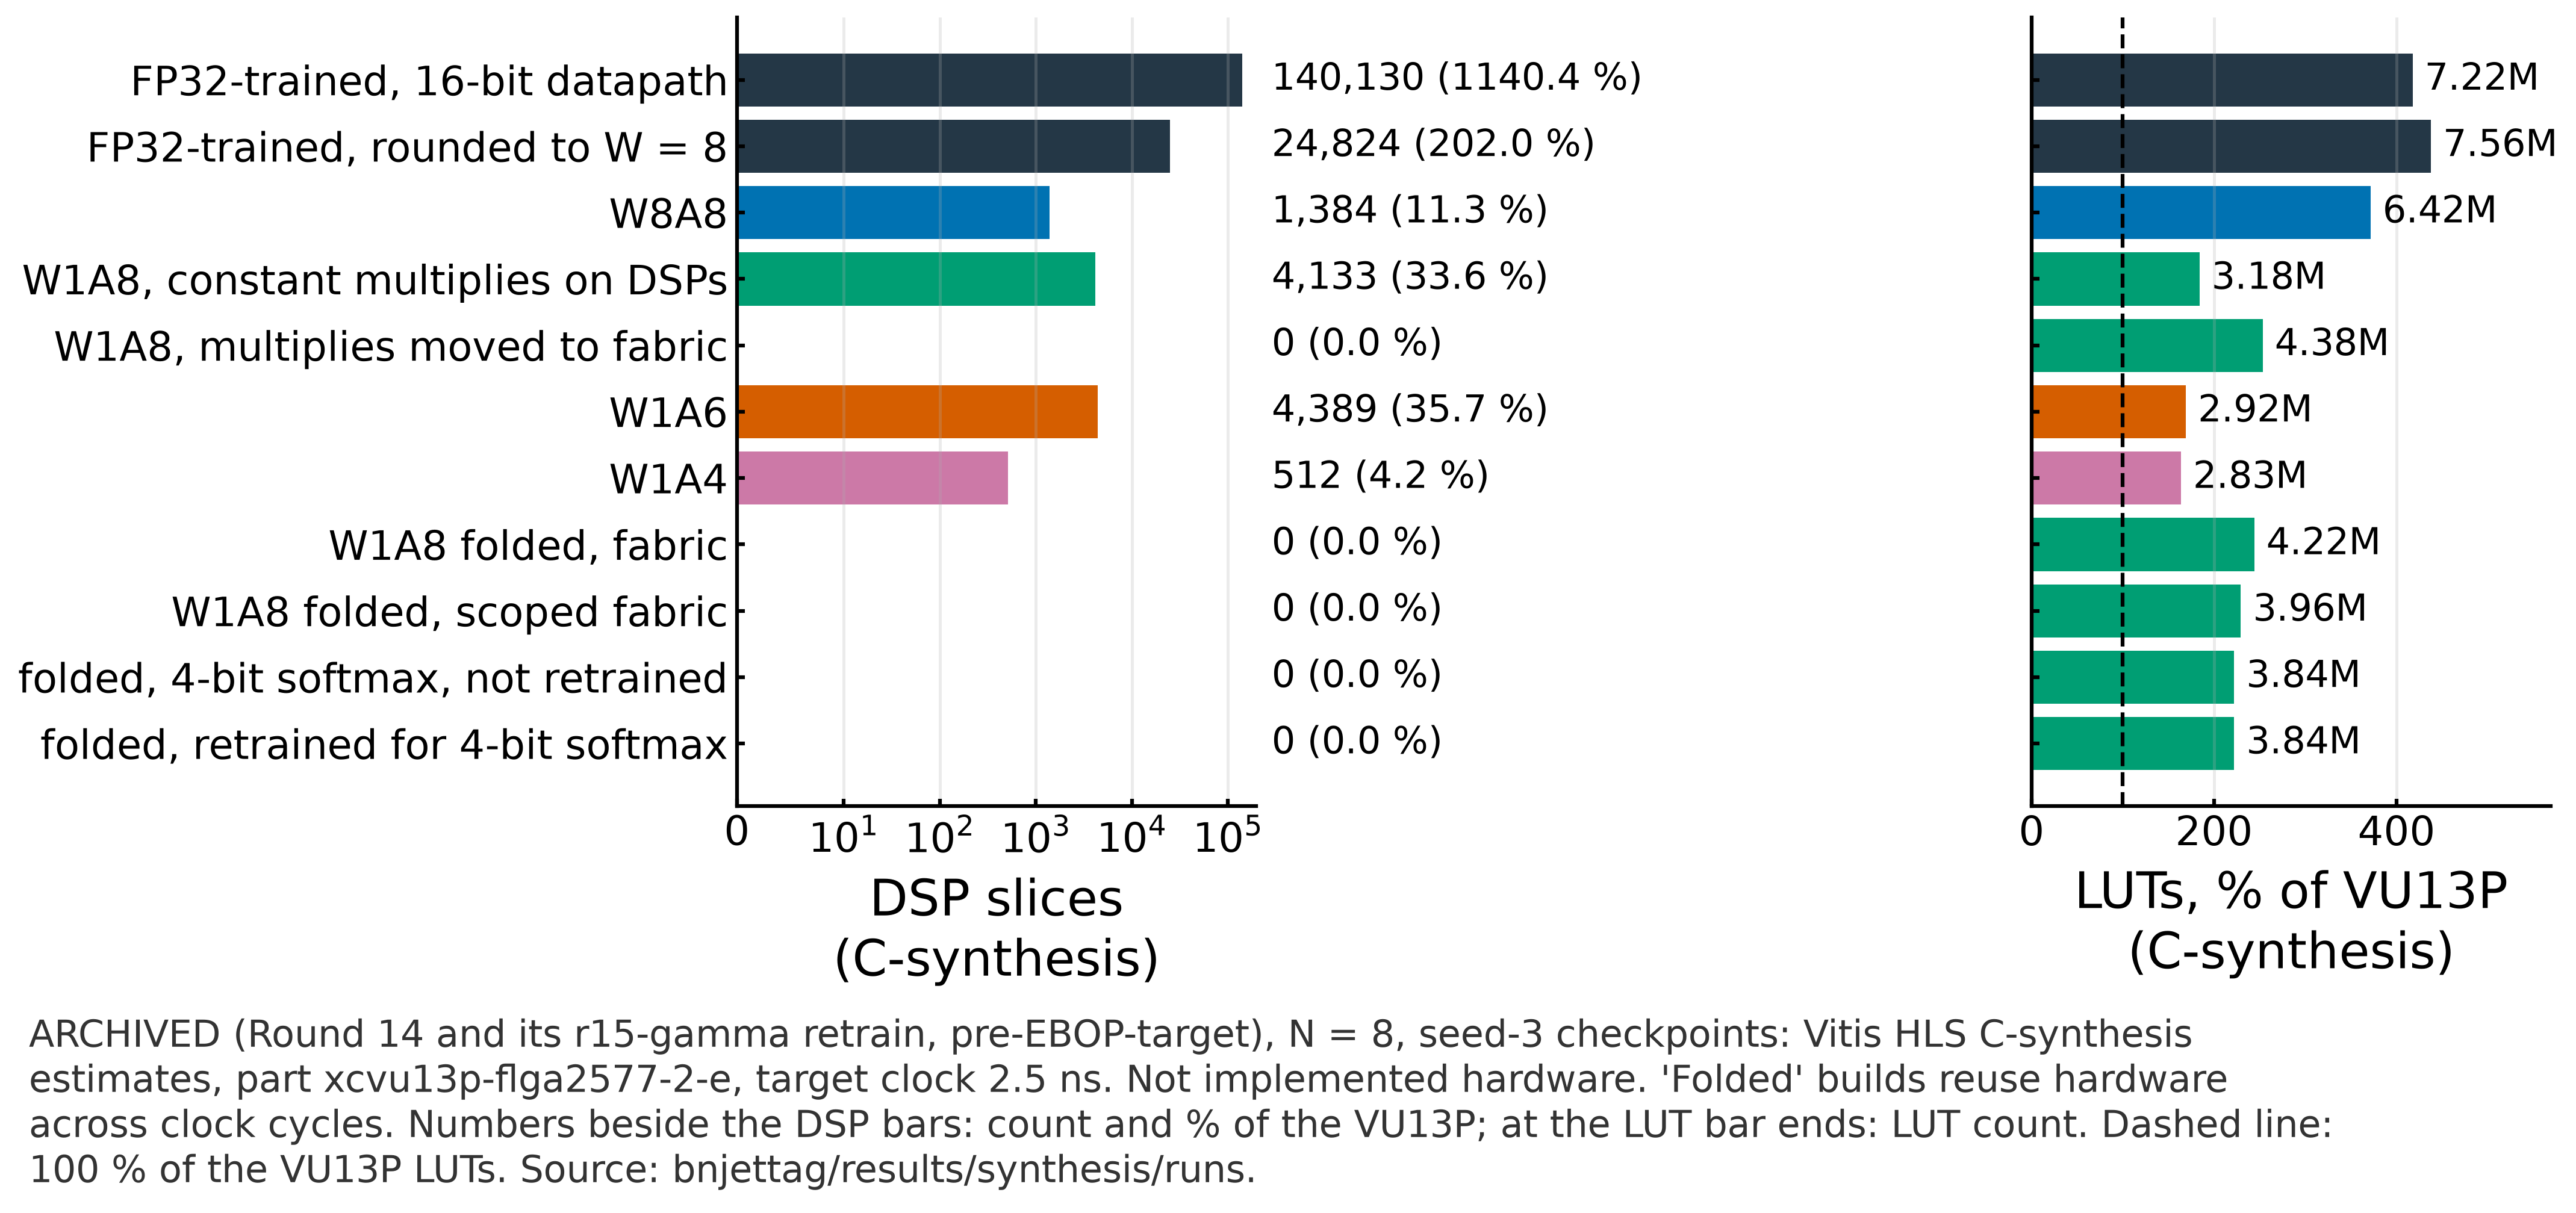

**Figure 4.** Archived Round-14 C-synthesis: DSP slices (left, symmetric-log axis) and LUTs as a share of the VU13P (right). Binding the constant multiplies to fabric takes W1A8 at II = 1 from 4,133 DSP to 0, for +1,197,502 LUT. 5 of the 11 builds shown have 0 DSP, all binary-weight. W8A8 needs 1,384 DSP and the FP32-trained 16-bit datapath 140,130 (1140 % of the VU13P). Every build shown is above 100 % of the VU13P LUTs at C-synthesis. These are estimates, not implemented hardware.

In [9]:
d_def = next(r for r in cs if r["dir"].endswith("w1a8-s3-r14n8/csynth_rf1"))
d_fab = next(r for r in cs if r["dir"].endswith("w1a8-s3-r14n8/csynth_rf1_fabric"))
w8 = next(r for r in cs if r["family"] == "W8A8")
fp16 = next(r for r in cs if r["dir"].endswith("fp32-s3-r14n8-w16/csynth_rf1"))
zero = [r for r in sel if r["DSP"] == 0]
all_over = min(r["LUT_pct"] for r in sel) > 100
png = H.fig_csynth(cs)
show(png, f"**Figure 4.** Archived Round-14 C-synthesis: DSP slices (left, symmetric-log axis) and LUTs as a share of the "
          f"VU13P (right). Binding the constant multiplies to fabric takes W1A8 at II = 1 from {d_def['DSP']:,} DSP to "
          f"{d_fab['DSP']:,}, for {d_fab['LUT'] - d_def['LUT']:+,} LUT. {len(zero)} of the {len(sel)} builds shown have "
          f"0 DSP, all binary-weight. W8A8 needs {w8['DSP']:,} DSP and the FP32-trained 16-bit datapath {fp16['DSP']:,} "
          f"({fp16['DSP_pct']:.0f} % of the VU13P). "
          + ("Every build shown is above 100 % of the VU13P LUTs at C-synthesis. " if all_over else "")
          + "These are estimates, not implemented hardware.")

In [10]:
viv = H.load_vivado(p0["avail"]["LUT"])
md("**Archived, Vivado synthesis** (2023.2, out of context, pre-route). It ran on the xczu7ev because no VU13P "
   "licence was available, so the part is a proxy: the LUT share is taken against the VU13P LUT count from the csynth "
   "reports, and a DSP count equal to the part's available count means Vivado ran out of DSPs. Where it did, the "
   "demand column quotes Vivado's own over-utilization line from the saved log. WNS is from the saved timing report at "
   "the same stage (positive = timing met at that clock).")
tab = [[f"`{r['build']}`", r["stage"], r["device"], f"{r['LUT']:,} ({r['LUT_vu13p_pct']:.1f} % of VU13P)",
        f"{r['DSP']:,} / {r['DSP_avail']:,}", f"{r['DSP_demand']:,}" if r["DSP_demand"] else "none logged",
        f"{r['clk']:g}" if r["clk"] else "not in run dir", f"{r['wns']:+.3f}" if r["wns"] is not None else "not saved"]
       for r in viv]
md(H.md_table(["build (run directory)", "stage", "part", "CLB LUT", "DSP used / available", "DSP demand", "clock (ns)",
               "WNS (ns)"], tab))
fit = [r for r in viv if r["DSP"] == 0 and r["LUT_vu13p_pct"] < 100]
if fit:
    md("Zero-DSP builds under the VU13P LUT count at this stage: " + "; ".join(
        f"`{r['build']}` {r['LUT_vu13p_pct']:.1f} % at {r['clk']:g} ns, WNS {r['wns']:+.3f} ns" for r in fit)
       + ". Pre-route, out-of-context, proxy part: a fit estimate, not a placed and routed design.")

**Archived, Vivado synthesis** (2023.2, out of context, pre-route). It ran on the xczu7ev because no VU13P licence was available, so the part is a proxy: the LUT share is taken against the VU13P LUT count from the csynth reports, and a DSP count equal to the part's available count means Vivado ran out of DSPs. Where it did, the demand column quotes Vivado's own over-utilization line from the saved log. WNS is from the saved timing report at the same stage (positive = timing met at that clock).

| build (run directory) | stage | part | CLB LUT | DSP used / available | DSP demand | clock (ns) | WNS (ns) |
|---|---|---|---|---|---|---|---|
| `38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev` | post-synth | xczu7ev-ffvc1156-2-e | 1,869,030 (108.2 % of VU13P) | 1,728 / 1,728 | 8,229 | 2.5 | +0.164 |
| `38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev_fabric` | post-synth | xczu7ev-ffvc1156-2-e | 2,011,660 (116.4 % of VU13P) | 0 / 1,728 | none logged | 2.5 | -0.145 |
| `38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev_fabric_v2` | post-opt | xczu7ev-ffvc1156-2-e | 2,108,743 (122.0 % of VU13P) | 0 / 1,728 | none logged | 2.5 | -0.967 |
| `38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev` | post-opt | xczu7ev-ffvc1156-2-e | 1,694,625 (98.1 % of VU13P) | 0 / 1,728 | none logged | 2.5 | -1.943 |
| `38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev_5ns` | post-opt | xczu7ev-ffvc1156-2-e | 1,583,181 (91.6 % of VU13P) | 0 / 1,728 | none logged | 5 | +0.557 |
| `38a20c62/w1a8-s3-r14n8-pf1fab/postsyn_xczu7ev` | post-opt | xczu7ev-ffvc1156-2-e | 1,948,063 (112.7 % of VU13P) | 0 / 1,728 | none logged | not in run dir | -1.922 |
| `38a20c62/w1a8-s3-r14n8-pf1scoped/postsyn_xczu7ev` | post-opt | xczu7ev-ffvc1156-2-e | 1,797,874 (104.0 % of VU13P) | 1,728 / 1,728 | 4,096 | 2.5 | -2.076 |
| `9cc6e336/w8a8-s3-r14n8/postsyn_xczu7ev` | post-opt | xczu7ev-ffvc1156-2-e | 2,525,842 (146.2 % of VU13P) | 1,721 / 1,728 | 5,550 | 2.5 | -1.086 |
| `ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev` | post-opt | xczu7ev-ffvc1156-2-e | 1,689,320 (97.8 % of VU13P) | 0 / 1,728 | none logged | 2.5 | -1.853 |
| `ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev_5ns` | post-opt | xczu7ev-ffvc1156-2-e | 1,583,565 (91.6 % of VU13P) | 0 / 1,728 | none logged | 5 | +0.647 |

Zero-DSP builds under the VU13P LUT count at this stage: `38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev` 98.1 % at 2.5 ns, WNS -1.943 ns; `38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev_5ns` 91.6 % at 5 ns, WNS +0.557 ns; `ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev` 97.8 % at 2.5 ns, WNS -1.853 ns; `ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev_5ns` 91.6 % at 5 ns, WNS +0.647 ns. Pre-route, out-of-context, proxy part: a fit estimate, not a placed and routed design.

## 4. What worked and what did not

One row per campaign, newest questions last. The verdict column says only what the saved
source supports; open work is marked open.

In [11]:
ptw = H.load_ptw()
ch = H.load_chang()
bench = H.load_bench()
dc = H.load_delta_canary()
cst = H.load_constituent()
g5a, gNa = ptw["gaps"][("PTW5", "auc")], ptw["gaps"][("PTWNC", "auc")]
g5c, gNc = ptw["gaps"][("PTW5", "acc")], ptw["gaps"][("PTWNC", "acc")]
ns = len(ptw["seeds"])
total_cst = next((n for k, n in cst["counts"] if k.lower().startswith("total")), None)
done_cst = next((n for k, n in cst["counts"] if k.lower().startswith("completed all")), None)
a02 = conf["rows"][0]
under = [a for a in ch["arms"] if a["target"] and np.nanmin(np.where(np.isnan(a["traced"]), np.inf, a["traced"])) <= a["target"]]
feas = [a for a in ch["arms"] if np.nansum(a["feasible"]) > 0]
last_ep = [int(a["epoch"].max()) for a in ch["arms"]]
k3 = next(iter(dc["phases"].values())) if dc and dc["phases"] else {}
chang_verify = (H.REPO / "campaigns/2026-09-26-training-batch/VERIFY.md").exists()
bench_verify = (H.REPO / "campaigns/2026-09-29-gpu-benchmark/VERIFY.md").exists()
rows_w = [
    ["EBOP-constrained ablation, N = %d, %s EBOPs target" % (cur["n_part"], f"{B:,}"),
     f"All {n_under} of {len(rows)} arms at or under the target. Highest held-out AUC {best_auc['short']} "
     f"{best_auc['test_auc']:.4f}; highest held-out accuracy {best_acc['short']} {H.pct(best_acc['test_acc'])} (n = {NT:,}).",
     ("Budget met by every arm" if n_under == len(rows) else f"Budget met by {n_under} of {len(rows)} arms")
     + "; no arm shown better than another (one seed each).",
     "verified (recomputed), single seed", f"`{H.ABL_DIR}/`"],
    ["Final-layer refit on the channel-wise checkpoint",
     f"{100 * head['d_acc']:+.2f} pp held-out accuracy [{100 * head['lo']:+.2f}, {100 * head['hi']:+.2f}] "
     f"(event-level 95 %), AUC {head['auc']:.4f}, {head['ebops']:,} EBOPs.",
     "Small gain, but the last layer is no longer binary; seed spread unknown.",
     "verified (recomputed), single seed", f"`{H.HEAD_NPZ}`"],
    ["pT reweighting (Round-14 N = 8 W1A8 config, no EBOP target)",
     f"Held-out (ROC-test) macro-OvR AUC vs unweighted: {H.PTW_PLAIN['PTW5']} {g5a['mean']:+.4f} [{g5a['lo']:+.4f}, "
     f"{g5a['hi']:+.4f}], {H.PTW_PLAIN['PTWNC']} {gNa['mean']:+.4f} "
     f"[{gNa['lo']:+.4f}, {gNa['hi']:+.4f}], lower on {g5a['lower']}/{ns} and {gNa['lower']}/{ns} seeds; accuracy "
     f"{100 * g5c['mean']:+.2f} and {100 * gNc['mean']:+.2f} pp (n = {ptw['n']:,}, 95 % paired t).",
     "Did not work: both weighted arms lose on every seed.",
     "verified (VERIFY.md and recomputed); analysis fixed after the results", "`campaigns/2026-09-25-pt-weighting/VERIFY.md`"],
    ["Matched N8/N64 constituent screen (one seed, short schedule)",
     f"{cst['verdict']} {done_cst} of {total_cst} intended cases completed the schedule.",
     "Did not reach the budget; its N = 64 memory signal went to the confirmation queue.",
     "reported (campaign summary, unreviewed)", f"`{H.CONST_DOC}`"],
    ["Confirmation campaign: deterministic re-evaluation",
     f"{a02['arm']}: {H.pct(a02['ho_acc'])} held-out accuracy, AUC {a02['ho_auc']:.4f} at {a02['ebops']:,} EBOPs "
     f"(n = {a02['n_ho']:,}, seed 1). Seed-confirmation runs: no evaluation saved on this machine.",
     "Best reported number under the target; not verified here and not seed-confirmed.",
     "reported (saved JSON, not recomputed)", f"`{H.CONF_EVAL}`"],
    ["Chang recipe (Sun et al.), regime-B pilots, N = %d" % ch["arms"][0]["n_part"],
     f"{len(ch['arms'])} arms logged to epochs {min(last_ep)}-{max(last_ep)} of {ch['arms'][0]['total']:,}; "
     f"{len(feas)} of {len(ch['arms'])} with a traced epoch flagged feasible by the trainer"
     + (" (" + ", ".join(f"arm {a['label']}: {H.CHANG_PLAIN.get(a['arm'], a['arm'])}, target {a['target']:,.0f}"
                         for a in feas) + ")." if feas else "."),
     ("A VERIFY.md now exists for this campaign; its verdicts supersede this telemetry row." if chang_verify else
      "Open: no VERIFY.md yet; the pre-registered readout at epoch 500 decides."),
     "telemetry, not a result", f"`{H.CHANG_LOGS}/`"],
    ["Delta memory canary (A07 model, several arms on one GPU)",
     f"{k3.get('k_tested')} arms on one {', '.join(k3.get('gpu_product', []))}: out of memory "
     f"{'yes' if k3.get('oom') else 'no'}; {k3.get('per_process_peak_mib', 0):,.0f} MiB per process, pod peak "
     f"{k3.get('pod_peak_mib', 0):,.0f} of {k3.get('card_mib', 0):,.0f} MiB; arms per GPU accepted: {k3.get('k_accepted')}.",
     f"{k3.get('k_tested')} arms per GPU do not fit; {k3.get('k_accepted')} do.",
     "telemetry (sizes packs; not a result)", f"`{dc['file'] if dc else H.DELTA_LOGS}`"],
    ["GPU benchmark (which GPU finishes first)",
     f"{len(bench)} completed phases saved across {len({r['job'] for r in bench})} Jobs "
     f"({', '.join(sorted({r['product'].replace('NVIDIA-', '') for r in bench}))}); "
     + ("every arm exited ok." if all(r["ok"] == r["k"] for r in bench) else "some arms did not exit ok."),
     ("A VERIFY.md now exists for this campaign; its verdict supersedes this row." if bench_verify else
      "Open: no VERIFY.md yet; the product choice comes from the benchmark's summary, not from these rates."),
     "telemetry, provisional", f"`{H.BENCH}/`"],
]
md(H.md_table(["campaign", "what the saved data say", "verdict", "status", "source"], rows_w))

| campaign | what the saved data say | verdict | status | source |
|---|---|---|---|---|
| EBOP-constrained ablation, N = 8, 350,000 EBOPs target | All 7 of 7 arms at or under the target. Highest held-out AUC reduced FFN 0.8535; highest held-out accuracy channel-wise 58.74 % (n = 260,000). | Budget met by every arm; no arm shown better than another (one seed each). | verified (recomputed), single seed | `campaigns/2026-09-16-accuracy-investigation/remote-results/` |
| Final-layer refit on the channel-wise checkpoint | +0.40 pp held-out accuracy [+0.32, +0.47] (event-level 95 %), AUC 0.8560, 322,510 EBOPs. | Small gain, but the last layer is no longer binary; seed spread unknown. | verified (recomputed), single seed | `campaigns/2026-09-16-accuracy-investigation/head-features/head_test_predictions.npz` |
| pT reweighting (Round-14 N = 8 W1A8 config, no EBOP target) | Held-out (ROC-test) macro-OvR AUC vs unweighted: pT-weighted, cap 5 -0.0108 [-0.0124, -0.0093], pT-weighted, no cap -0.0125 [-0.0148, -0.0101], lower on 8/8 and 8/8 seeds; accuracy -1.54 and -1.84 pp (n = 260,000, 95 % paired t). | Did not work: both weighted arms lose on every seed. | verified (VERIFY.md and recomputed); analysis fixed after the results | `campaigns/2026-09-25-pt-weighting/VERIFY.md` |
| Matched N8/N64 constituent screen (one seed, short schedule) | No trained case recorded a feasible checkpoint at its configured target. 28 of 38 intended cases completed the schedule. | Did not reach the budget; its N = 64 memory signal went to the confirmation queue. | reported (campaign summary, unreviewed) | `publication/docs/current-work/CONSTITUENT_SCREEN_20260923.md` |
| Confirmation campaign: deterministic re-evaluation | batch20260917-a02-s1: 60.78 % held-out accuracy, AUC 0.8604 at 349,298 EBOPs (n = 260,000, seed 1). Seed-confirmation runs: no evaluation saved on this machine. | Best reported number under the target; not verified here and not seed-confirmed. | reported (saved JSON, not recomputed) | `campaigns/2026-09-23-confirmation/evaluation-results.json` |
| Chang recipe (Sun et al.), regime-B pilots, N = 64 | 8 arms logged to epochs 240-500 of 7,000; 4 of 8 with a traced epoch flagged feasible by the trainer (arm A-s2: E model, target 350,000, arm C-s1: A07 model, target 5,000,000, arm D-s1: E model, our optimizer, target 350,000, arm F-s1: E model + learned positions, target 350,000). | Open: no VERIFY.md yet; the pre-registered readout at epoch 500 decides. | telemetry, not a result | `campaigns/2026-09-26-training-batch/logs/` |
| Delta memory canary (A07 model, several arms on one GPU) | 3 arms on one NVIDIA A10: out of memory yes; 8,446 MiB per process, pod peak 22,545 of 23,028 MiB; arms per GPU accepted: 2. | 3 arms per GPU do not fit; 2 do. | telemetry (sizes packs; not a result) | `campaigns/2026-09-27-delta-screen/logs/20260929T0608Z-canary-a07_k_result.json` |
| GPU benchmark (which GPU finishes first) | 16 completed phases saved across 8 Jobs (A10, A100-SXM4-80GB, GeForce-RTX-3090, GeForce-RTX-4090, RTX-A6000); every arm exited ok. | Open: no VERIFY.md yet; the product choice comes from the benchmark's summary, not from these rates. | telemetry, provisional | `campaigns/2026-09-29-gpu-benchmark/logs/` |

**Check against the stored record** (`bnjettag/roc-results/ptw-n8/summary.json`): 24 of 24 per-seed held-out macro-OvR AUCs recomputed here agree with the stored values to 1e-9. The campaign's VERIFY.md (2026-09-26) recomputed the same arrays independently.

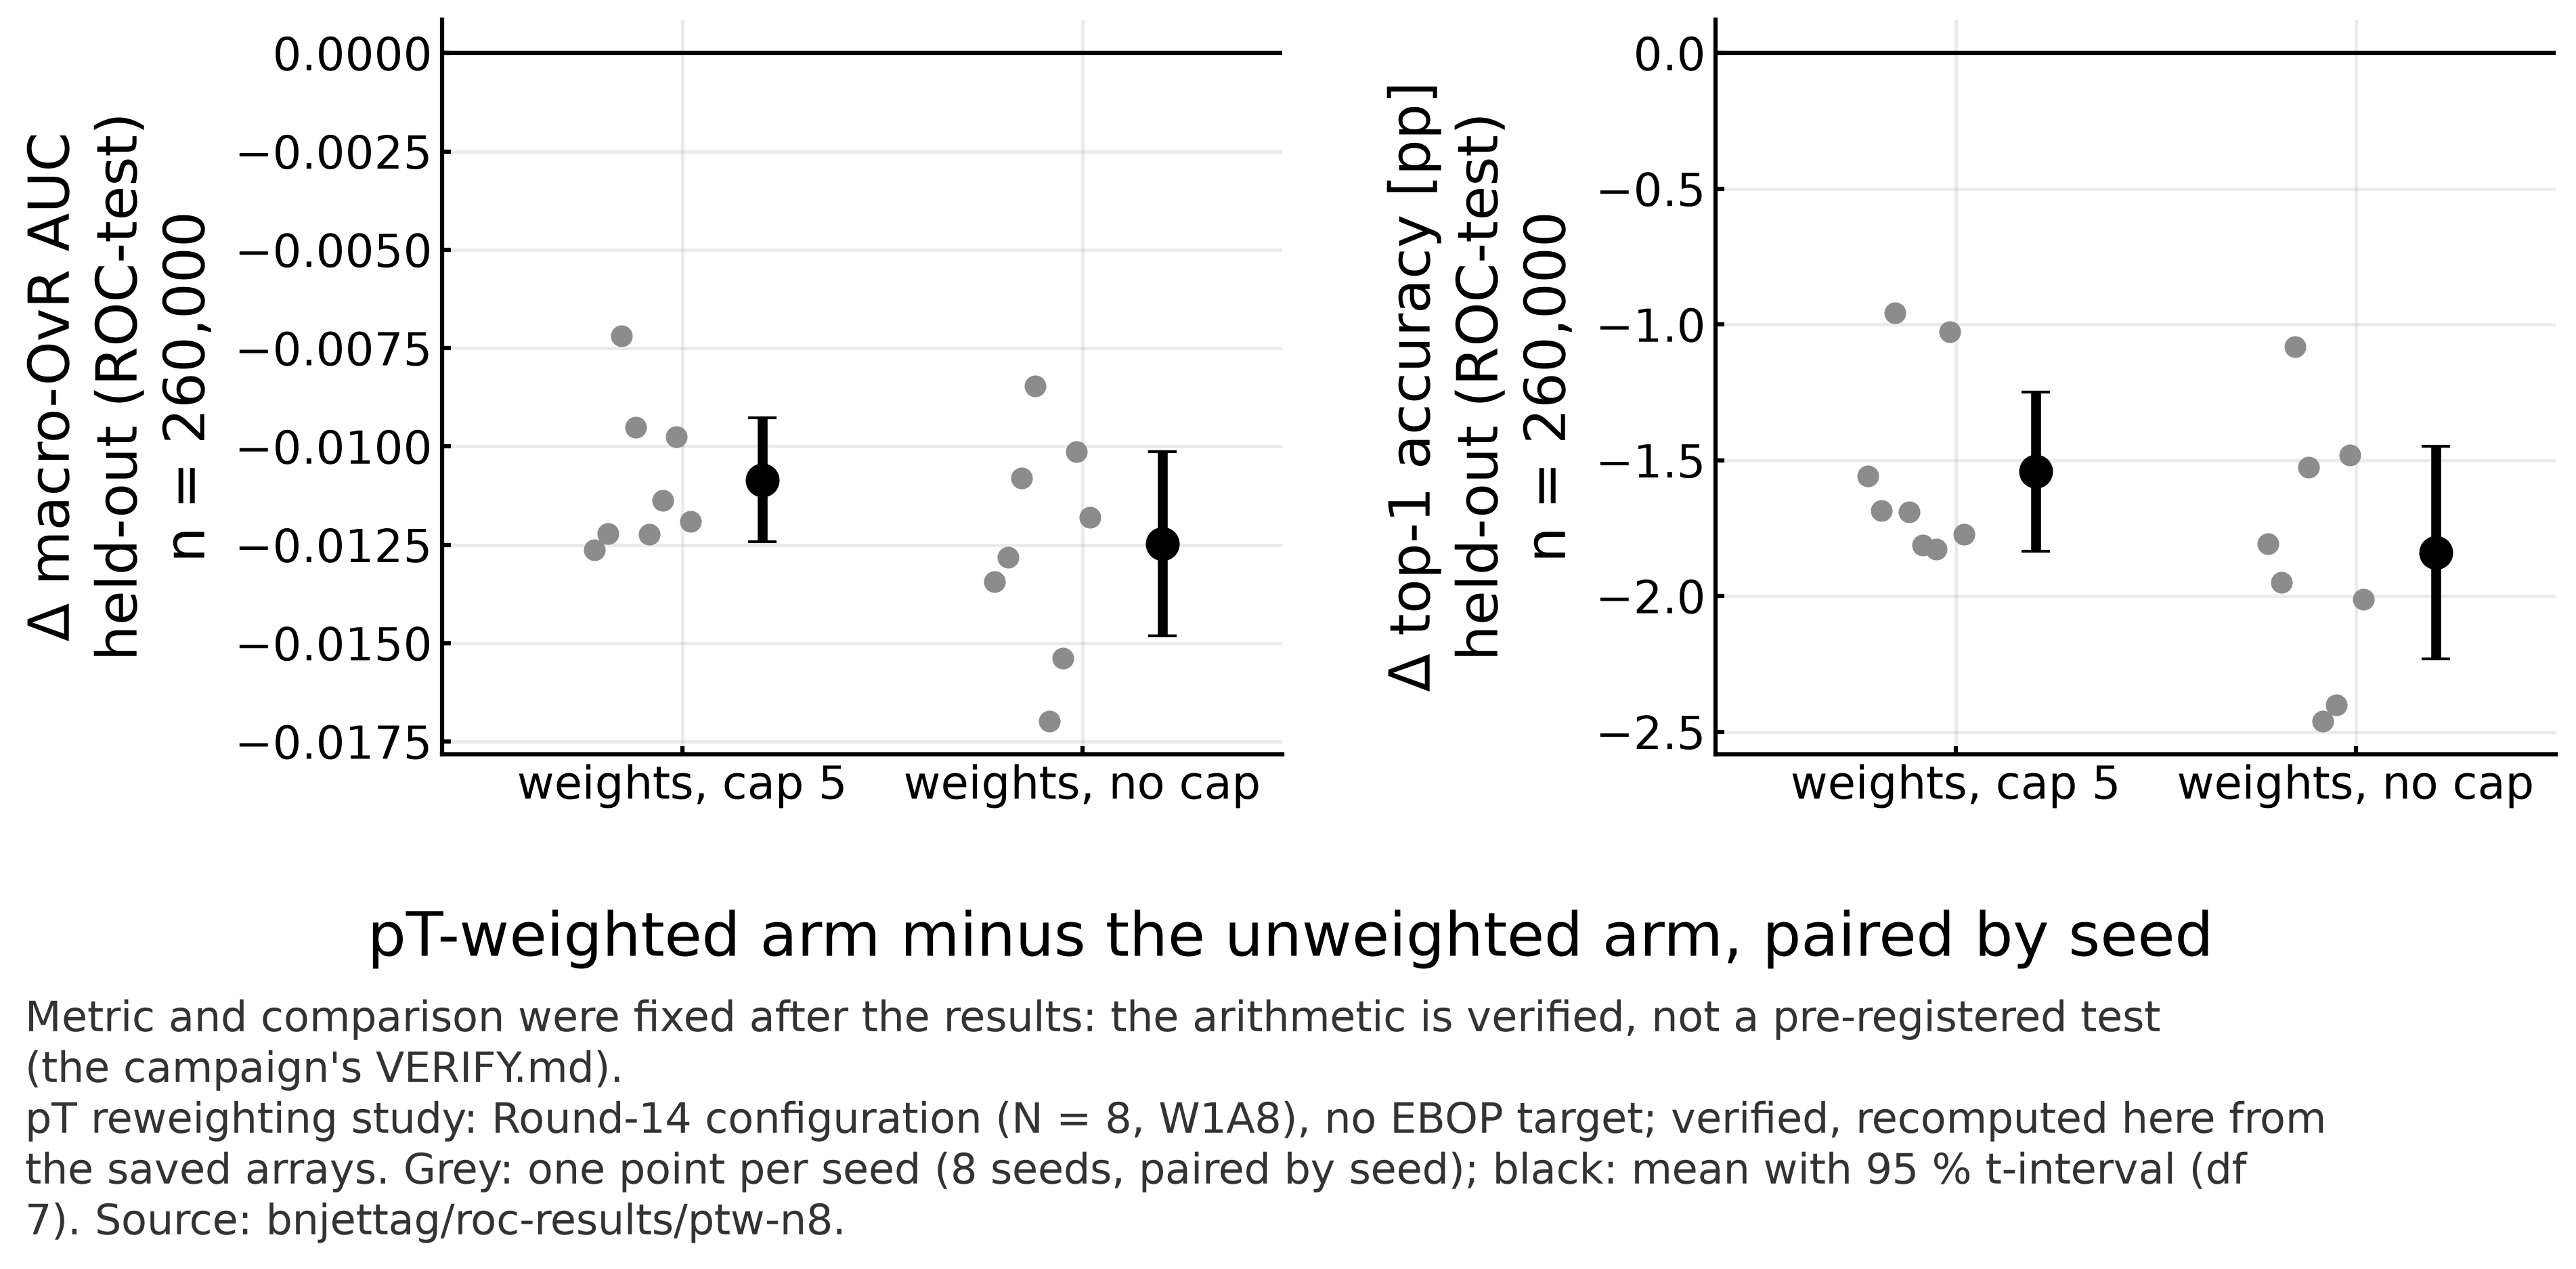

**Figure 5.** pT reweighting, checked in its VERIFY.md: paired differences to the unweighted arm on each of 8 seeds (grey) and their mean with a 95 % t-interval (black), held-out split, n = 260,000. Both weighted arms are lower on 8/8 and 8/8 seeds in macro-OvR AUC (pT-weighted, cap 5 -0.0108 [-0.0124, -0.0093], pT-weighted, no cap -0.0125 [-0.0148, -0.0101]). The metric and comparison were fixed after the results, so this confirms the arithmetic, not a pre-registered test. Round-14 configuration, not EBOP-constrained.

In [12]:
n_match = sum(abs(ptw["per"][(a, s)]["auc"] - ptw["claim"][a][s - 1]) < 1e-9 for a in H.PTW_ARMS for s in ptw["seeds"])
md(f"**Check against the stored record** (`{H.PTW}/summary.json`): {n_match} of {len(H.PTW_ARMS) * ns} per-seed held-out "
   f"macro-OvR AUCs recomputed here agree with the stored values to 1e-9. The campaign's VERIFY.md (2026-09-26) "
   "recomputed the same arrays independently.")
png = H.fig_ptw_gaps(ptw)
show(png, f"**Figure 5.** pT reweighting, checked in its VERIFY.md: paired differences to the unweighted arm on each of "
          f"{ns} seeds (grey) and their mean with a 95 % t-interval (black), held-out split, n = {ptw['n']:,}. Both "
          f"weighted arms are lower on {g5a['lower']}/{ns} and {gNa['lower']}/{ns} seeds in macro-OvR AUC "
          f"({H.PTW_PLAIN['PTW5']} {g5a['mean']:+.4f} [{g5a['lo']:+.4f}, {g5a['hi']:+.4f}], {H.PTW_PLAIN['PTWNC']} "
          f"{gNa['mean']:+.4f} [{gNa['lo']:+.4f}, "
          f"{gNa['hi']:+.4f}]). The metric and comparison were fixed after the results, so this confirms the arithmetic, "
          "not a pre-registered test. Round-14 configuration, not EBOP-constrained.")

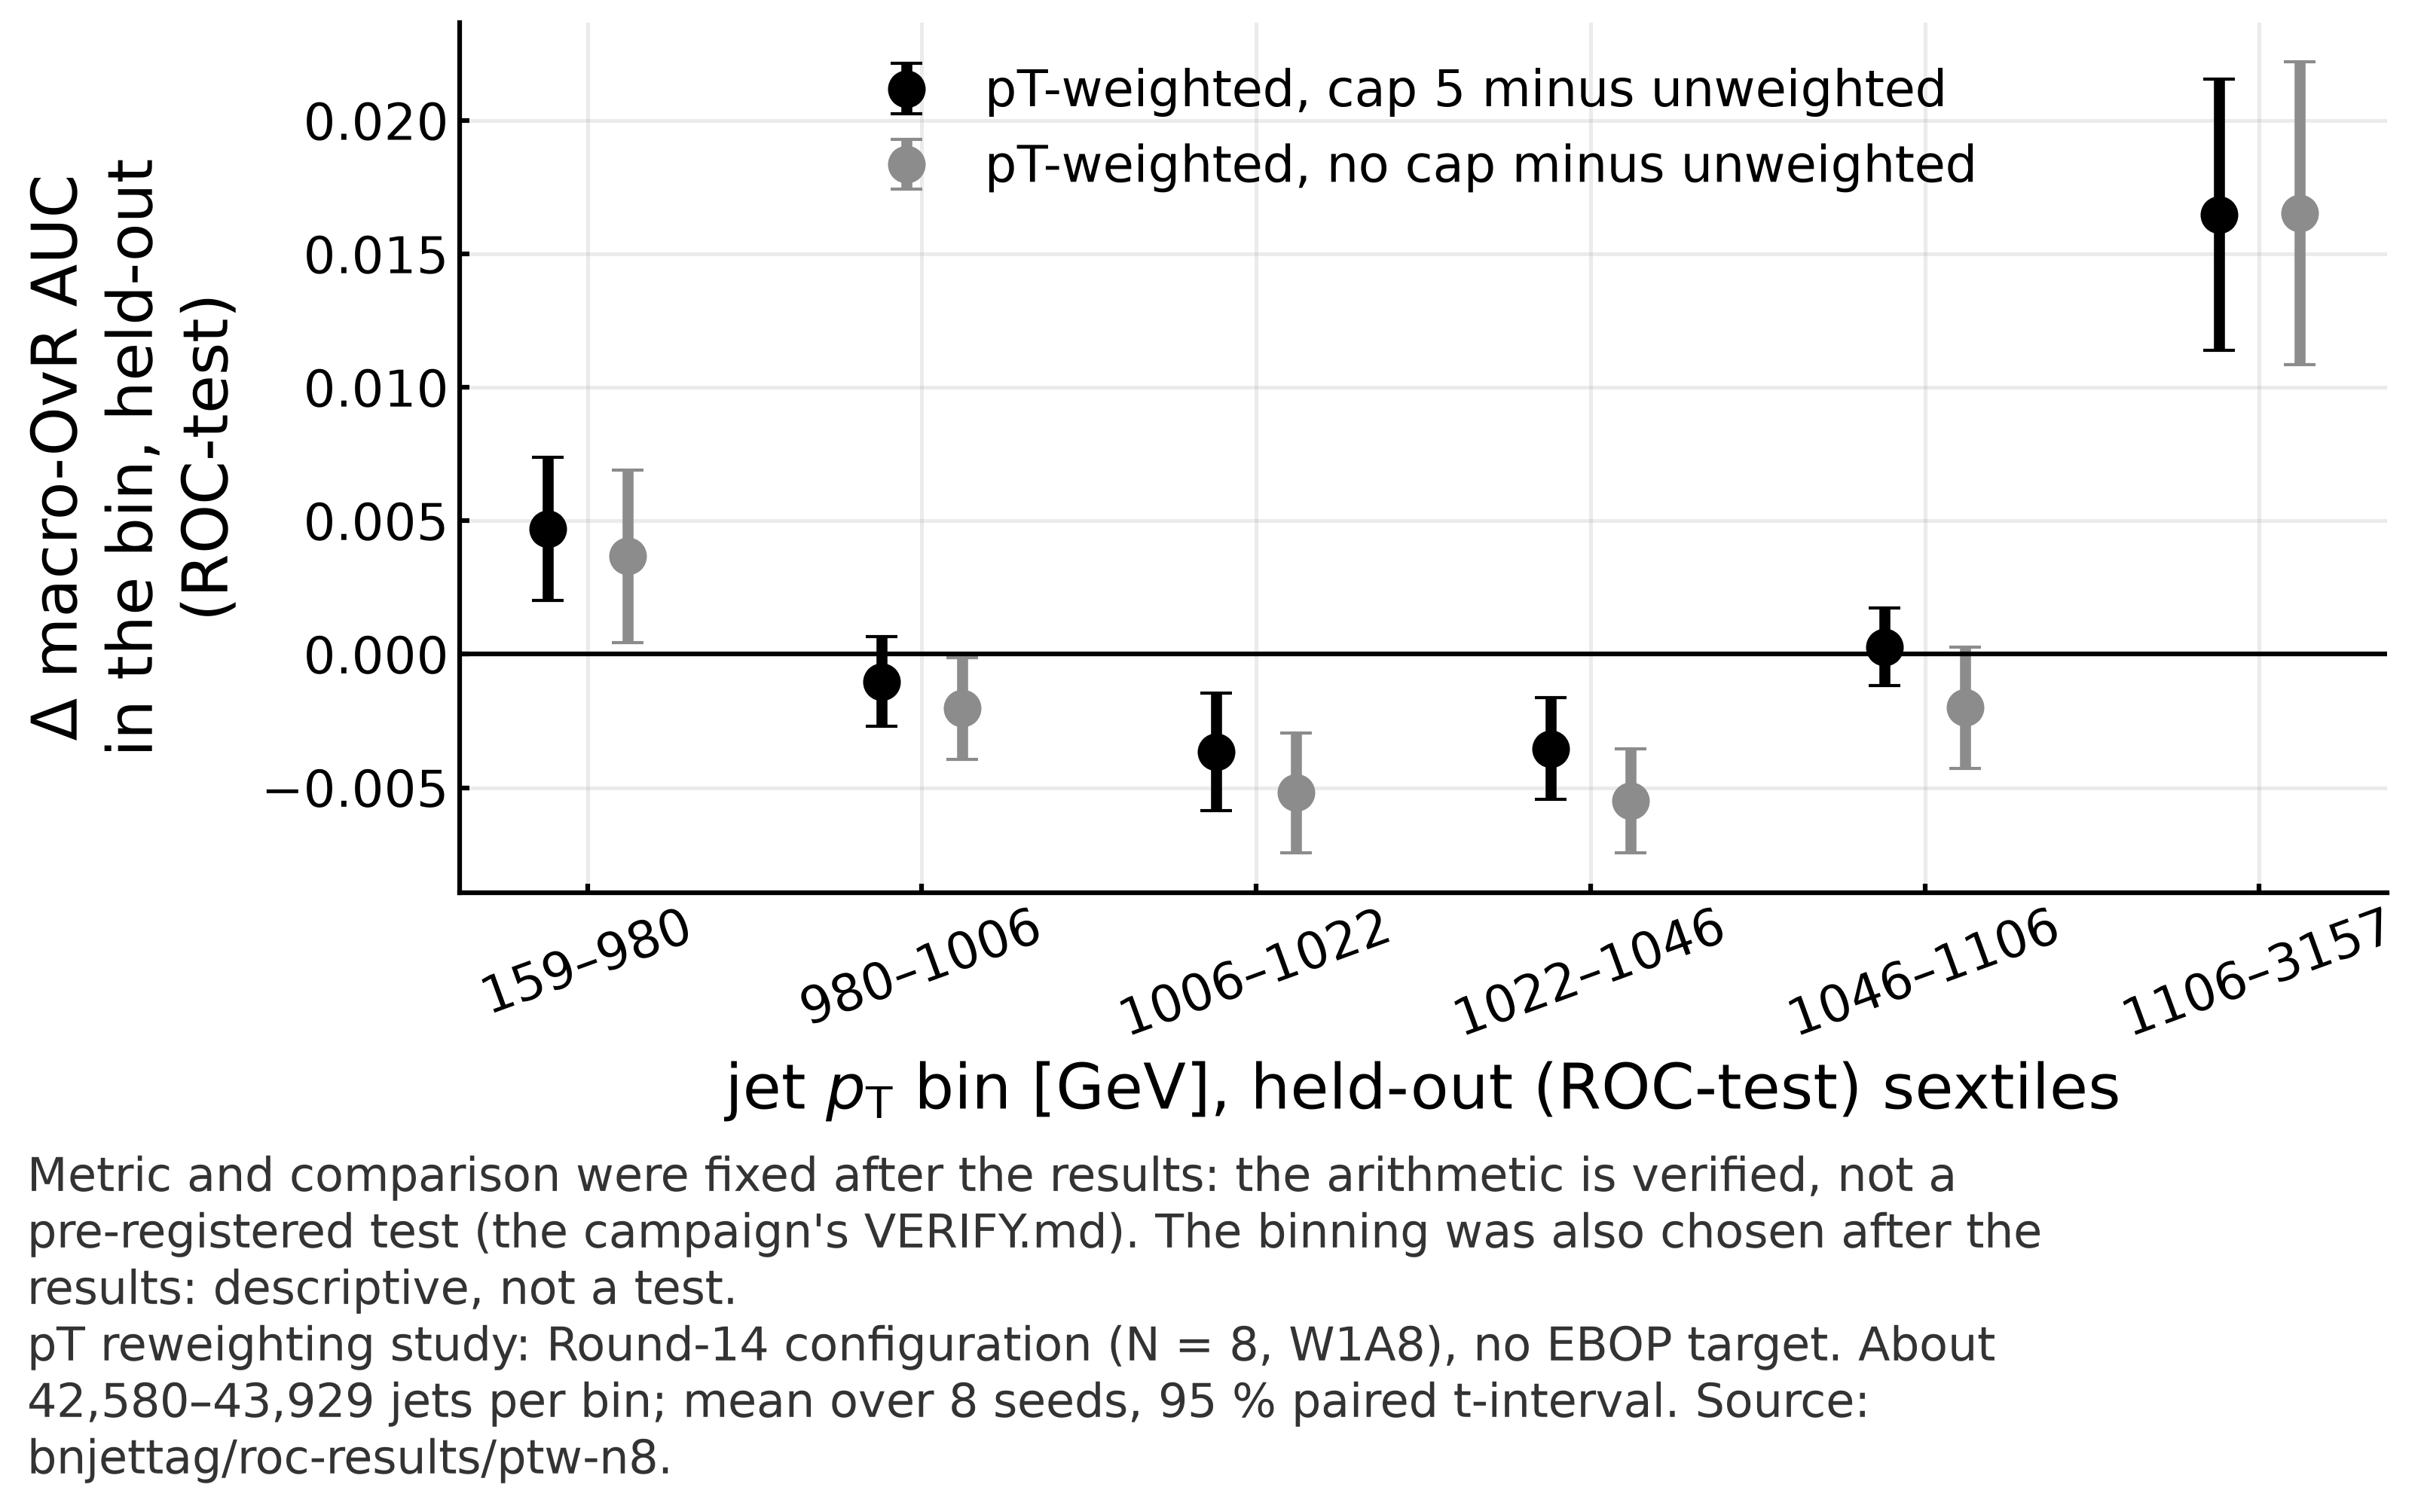

**Figure 6.** Held-out macro-OvR AUC difference to BASE inside each jet-pT sextile (GeV), mean over 8 seeds with a 95 % paired t-interval. For pT-weighted, cap 5 the interval lies above zero in bins 159–980, 1106–3157 and below zero in 1006–1022, 1022–1046; the top bin gains +0.0165 [+0.0114, +0.0215]. The weighting trades the centre of the pT range for its ends. The bins were chosen after the results, so this is description, not a test.

In [13]:
def bins_where(arm, sign):
    out = []
    for i, t in enumerate(ptw["bin_gaps"][arm]):
        if (sign > 0 and t["lo"] > 0) or (sign < 0 and t["hi"] < 0):
            out.append(f"{ptw['lo'][i]:.0f}–{ptw['hi'][i]:.0f}")
    return ", ".join(out) or "none"


png = H.fig_ptw_bins(ptw)
t6 = ptw["bin_gaps"]["PTW5"][-1]
show(png, f"**Figure 6.** Held-out macro-OvR AUC difference to BASE inside each jet-pT sextile (GeV), mean over {ns} seeds "
          f"with a 95 % paired t-interval. For {H.PTW_PLAIN['PTW5']} the interval lies above zero in bins "
          f"{bins_where('PTW5', +1)} and "
          f"below zero in {bins_where('PTW5', -1)}; the top bin gains {t6['mean']:+.4f} [{t6['lo']:+.4f}, {t6['hi']:+.4f}]. "
          + ("The weighting trades the centre of the pT range for its ends. "
             if ptw["bin_gaps"]["PTW5"][0]["lo"] > 0 and t6["lo"] > 0 and any(t["hi"] < 0 for t in ptw["bin_gaps"]["PTW5"][1:-1])
             else "")
          + "The bins were chosen after the results, so this is description, not a test.")

## 5. Current pilot telemetry: Chang-recipe regime-B pilots

Pilot telemetry on the validation split, not a result. The curves come from the newest saved
copy of each arm's log. When an arm resumed after a restart, the later line for an epoch
replaces the earlier one.

In [14]:
tab = []
for a in ch["arms"]:
    tr = ~np.isnan(a["traced"])
    last_tr = (int(a["epoch"][tr][-1]), a["traced"][tr][-1]) if tr.any() else (None, None)
    nfeas = int(np.nansum(a["feasible"]))
    imax = int(np.nanargmax(a["val_acc"]))
    tab.append([a["label"], H.CHANG_PLAIN.get(a["arm"], a["arm"]), f"{a['target']:,.0f}" if a["target"] else "?", f"{int(a['epoch'].max())} / {a['total']:,}",
                f"{last_tr[1]:,.0f} (epoch {last_tr[0]})" if last_tr[0] else "none",
                f"{nfeas} of {int(tr.sum())}", H.pct(a["val_acc"][-1]),
                f"{H.pct(a['val_acc'][imax])} (epoch {int(a['epoch'][imax])})", a["attempts"], f"`{a['file'].split('/')[-1]}`"])
md(f"**Telemetry, not a result.** Validation = the pilots' internal split, n = {ch['n_val']:,} (the recipe's split, "
   f"not the {NV:,} of section 1). EBOPs are traced in full every few epochs; in between the log carries the "
   "in-training estimate. " + H.CHANG_KEY)
md(H.md_table(["arm", "model", "EBOPs target", "last epoch logged / schedule", "latest traced EBOPs", "traced epochs flagged feasible",
               f"last validation accuracy (n = {ch['n_val']:,})", f"peak validation accuracy (n = {ch['n_val']:,})",
               "attempts in log", "log file"], tab))

**Telemetry, not a result.** Validation = the pilots' internal split, n = 62,000 (the recipe's split, not the 124,000 of section 1). EBOPs are traced in full every few epochs; in between the log carries the in-training estimate. E: the small binary model (Chang-sized); A07: the wider binary model with learned positions. Every arm runs the Sun et al. schedule; arm codes as in the training-batch STUDY.md.

| arm | model | EBOPs target | last epoch logged / schedule | latest traced EBOPs | traced epochs flagged feasible | last validation accuracy (n = 62,000) | peak validation accuracy (n = 62,000) | attempts in log | log file |
|---|---|---|---|---|---|---|---|---|---|
| A-s1 | E model | 350,000 | 386 / 7,000 | 364,272 (epoch 380) | 0 of 39 | 20.26 % | 65.22 % (epoch 5) | 1 | `chang0926-a-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1455Z.log` |
| A-s2 | E model | 350,000 | 383 / 7,000 | 304,404 (epoch 380) | 5 of 39 | 20.26 % | 64.42 % (epoch 4) | 1 | `chang0926-a-n64-s2-kai-chang0926-pilotb5-42abed-0-20260929T1455Z.log` |
| A07-350-s1 | A07 model | 350,000 | 450 / 7,000 | 375,917 (epoch 450) | 0 of 46 | 20.26 % | 67.81 % (epoch 7) | 2 | `chang0926-a07-350-n64-s1-kai-chang0926-pilotb3-42abed-0-20260929T1455Z.log` |
| C-s1 | A07 model | 5,000,000 | 449 / 7,000 | 4,634,532 (epoch 440) | 43 of 45 | 51.78 % | 68.78 % (epoch 7) | 2 | `chang0926-c-n64-s1-kai-chang0926-pilotb3-42abed-0-20260929T1455Z.log` |
| C′-s1 | A07 model, old quantizer | 5,000,000 | 240 / 7,000 | 5,459,970 (epoch 240) | 0 of 25 | 57.18 % | 67.45 % (epoch 48) | 1 | `chang0926-cprime-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1455Z.log` |
| D-s1 | E model, our optimizer | 350,000 | 383 / 7,000 | 299,195 (epoch 380) | 13 of 39 | 26.39 % | 64.20 % (epoch 5) | 1 | `chang0926-d-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1455Z.log` |
| E1-s1 | E model, one head | 350,000 | 500 / 7,000 | 375,397 (epoch 500) | 0 of 51 | 30.53 % | 64.90 % (epoch 11) | 1 | `chang0926-e1-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1455Z.log` |
| F-s1 | E model + learned positions | 350,000 | 500 / 7,000 | 433,344 (epoch 500) | 1 of 51 | 27.95 % | 65.95 % (epoch 10) | 2 | `chang0926-f-n64-s1-kai-chang0926-pilotb3-42abed-0-20260929T1455Z.log` |

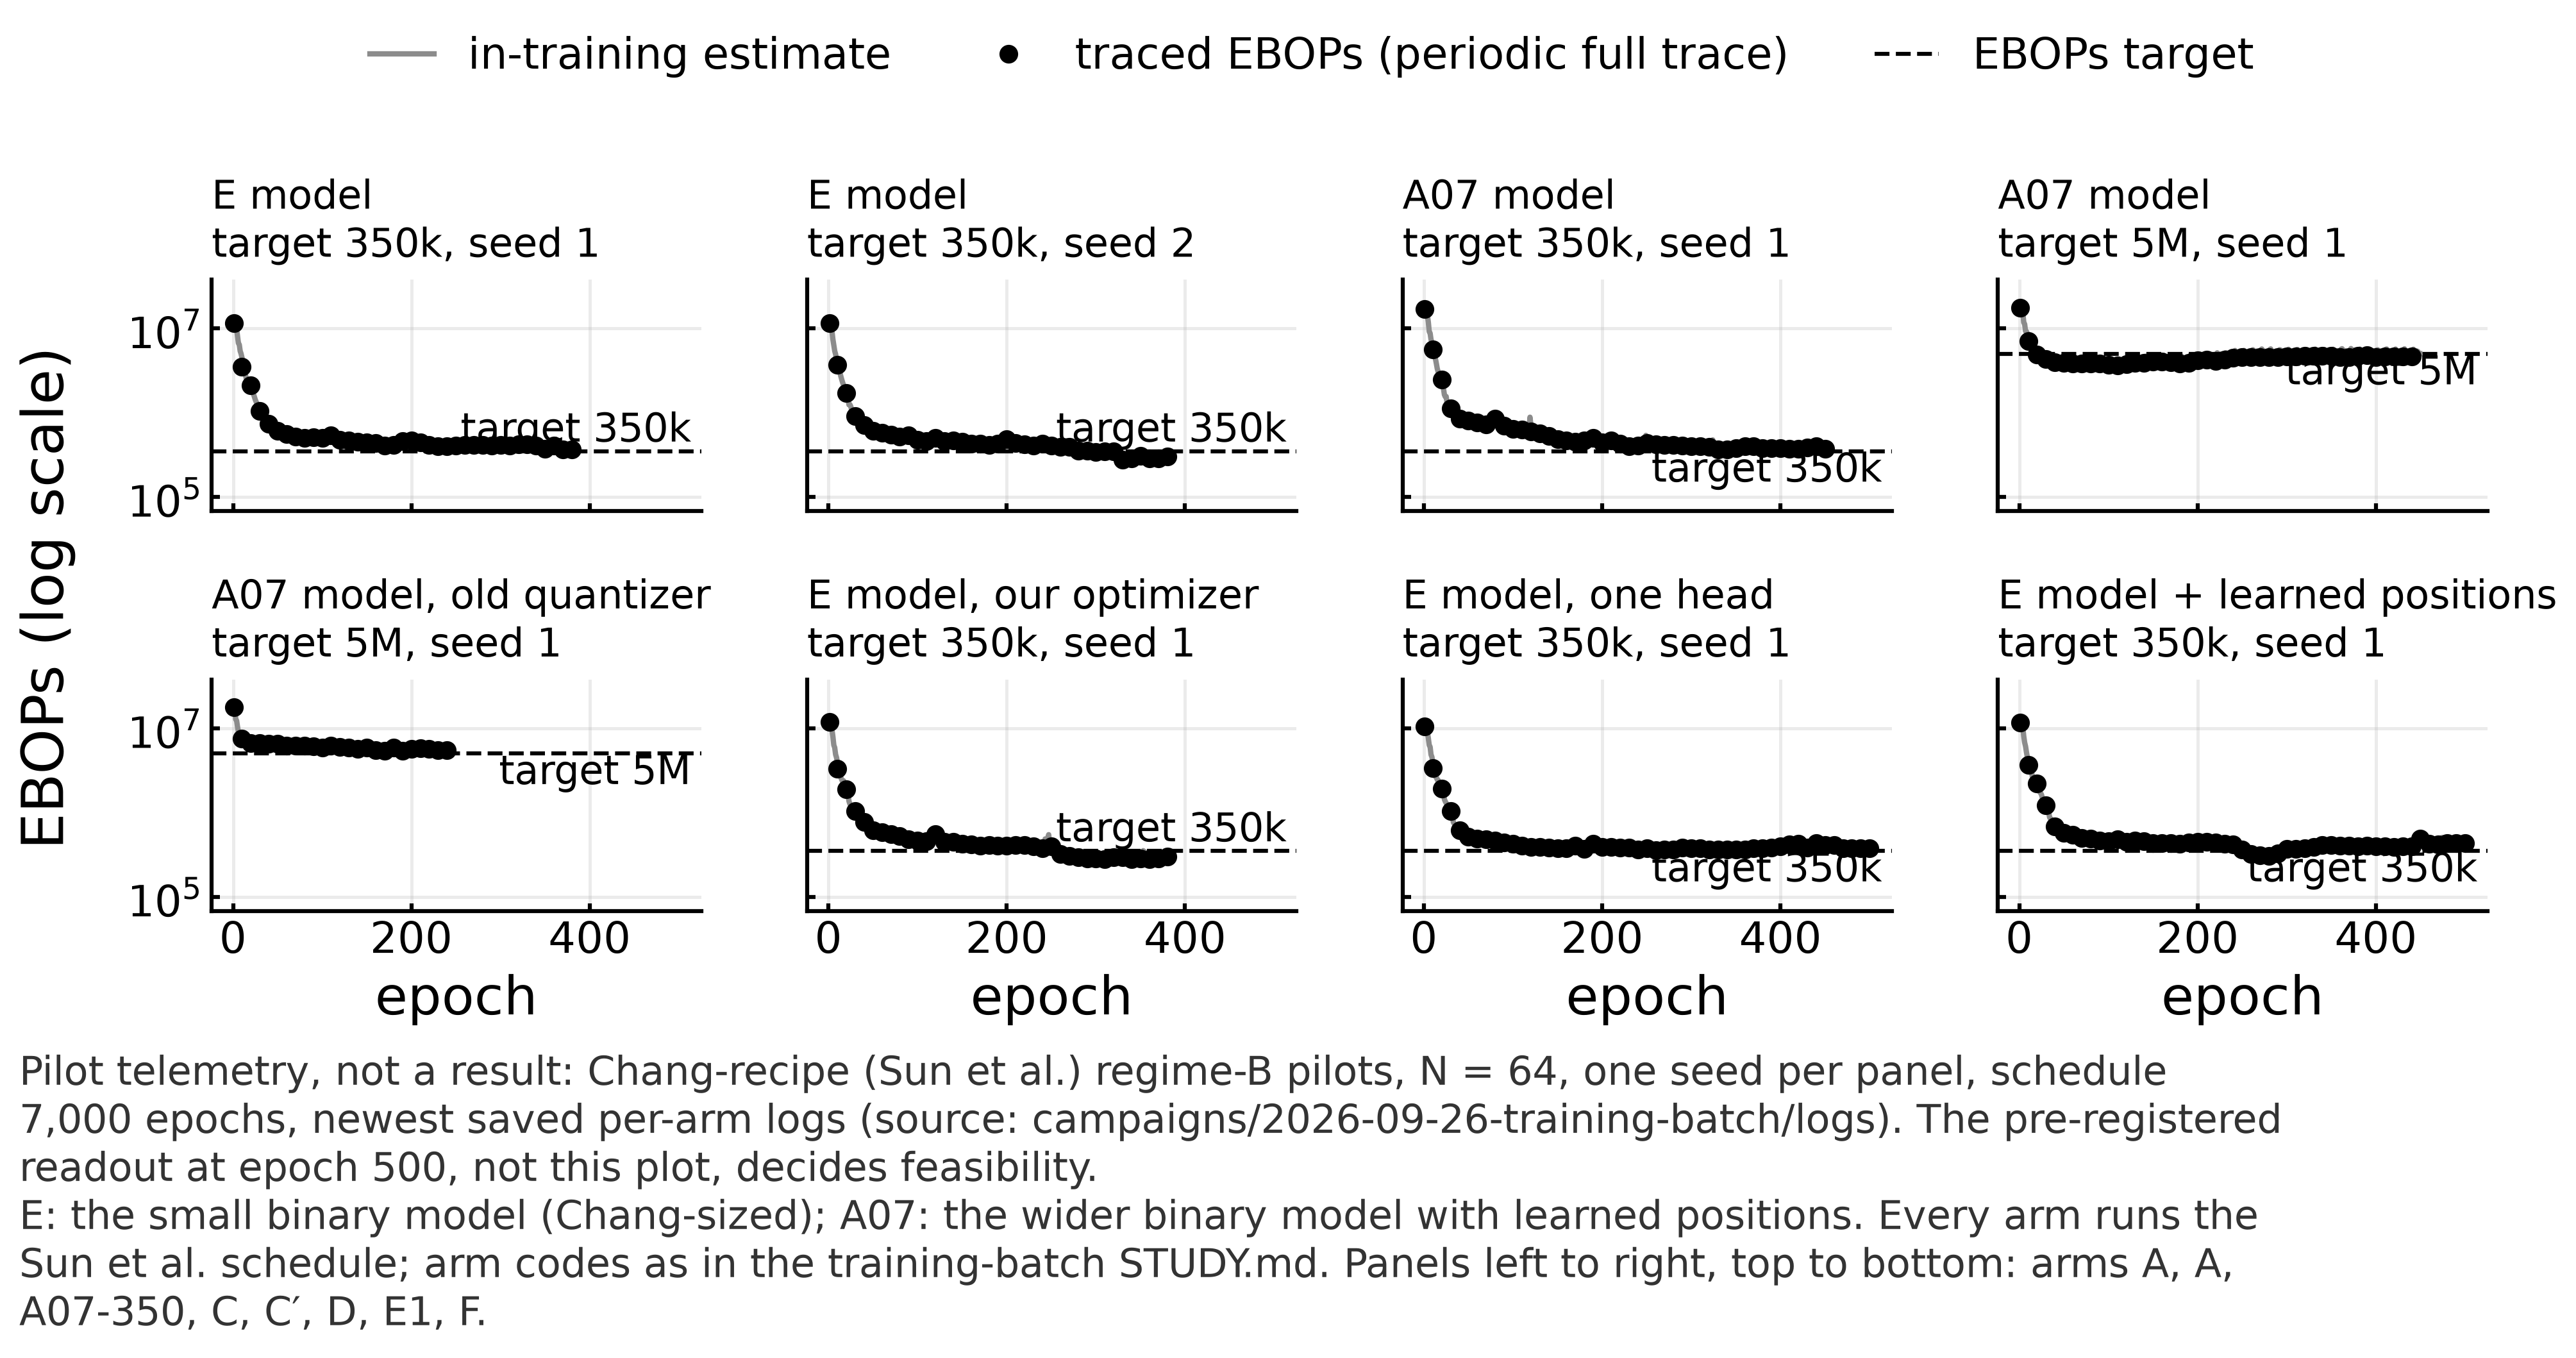

**Figure 7.** Pilot telemetry, not a result. Traced EBOPs (black points) and the in-training estimate (grey) per arm against its target (dashed), log scale. 4 of 8 arms have reached the target at a traced epoch (A-s2, C-s1, D-s1, F-s1); the rest are still above it. Feasibility is decided by the pre-registered readout at epoch 500, not by this plot.

In [15]:
png = H.fig_chang(ch, "ebops")
over = [a["label"] for a in ch["arms"] if a not in under]
show(png, f"**Figure 7.** Pilot telemetry, not a result. Traced EBOPs (black points) and the in-training estimate (grey) "
          f"per arm against its target (dashed), log scale. {len(under)} of {len(ch['arms'])} "
          f"arms {'has' if len(under) == 1 else 'have'} reached the target at a traced epoch "
          f"({', '.join(a['label'] for a in under) or 'none'}); the rest are still above it. "
          "Feasibility is decided by the pre-registered readout at epoch 500, not by this plot.")

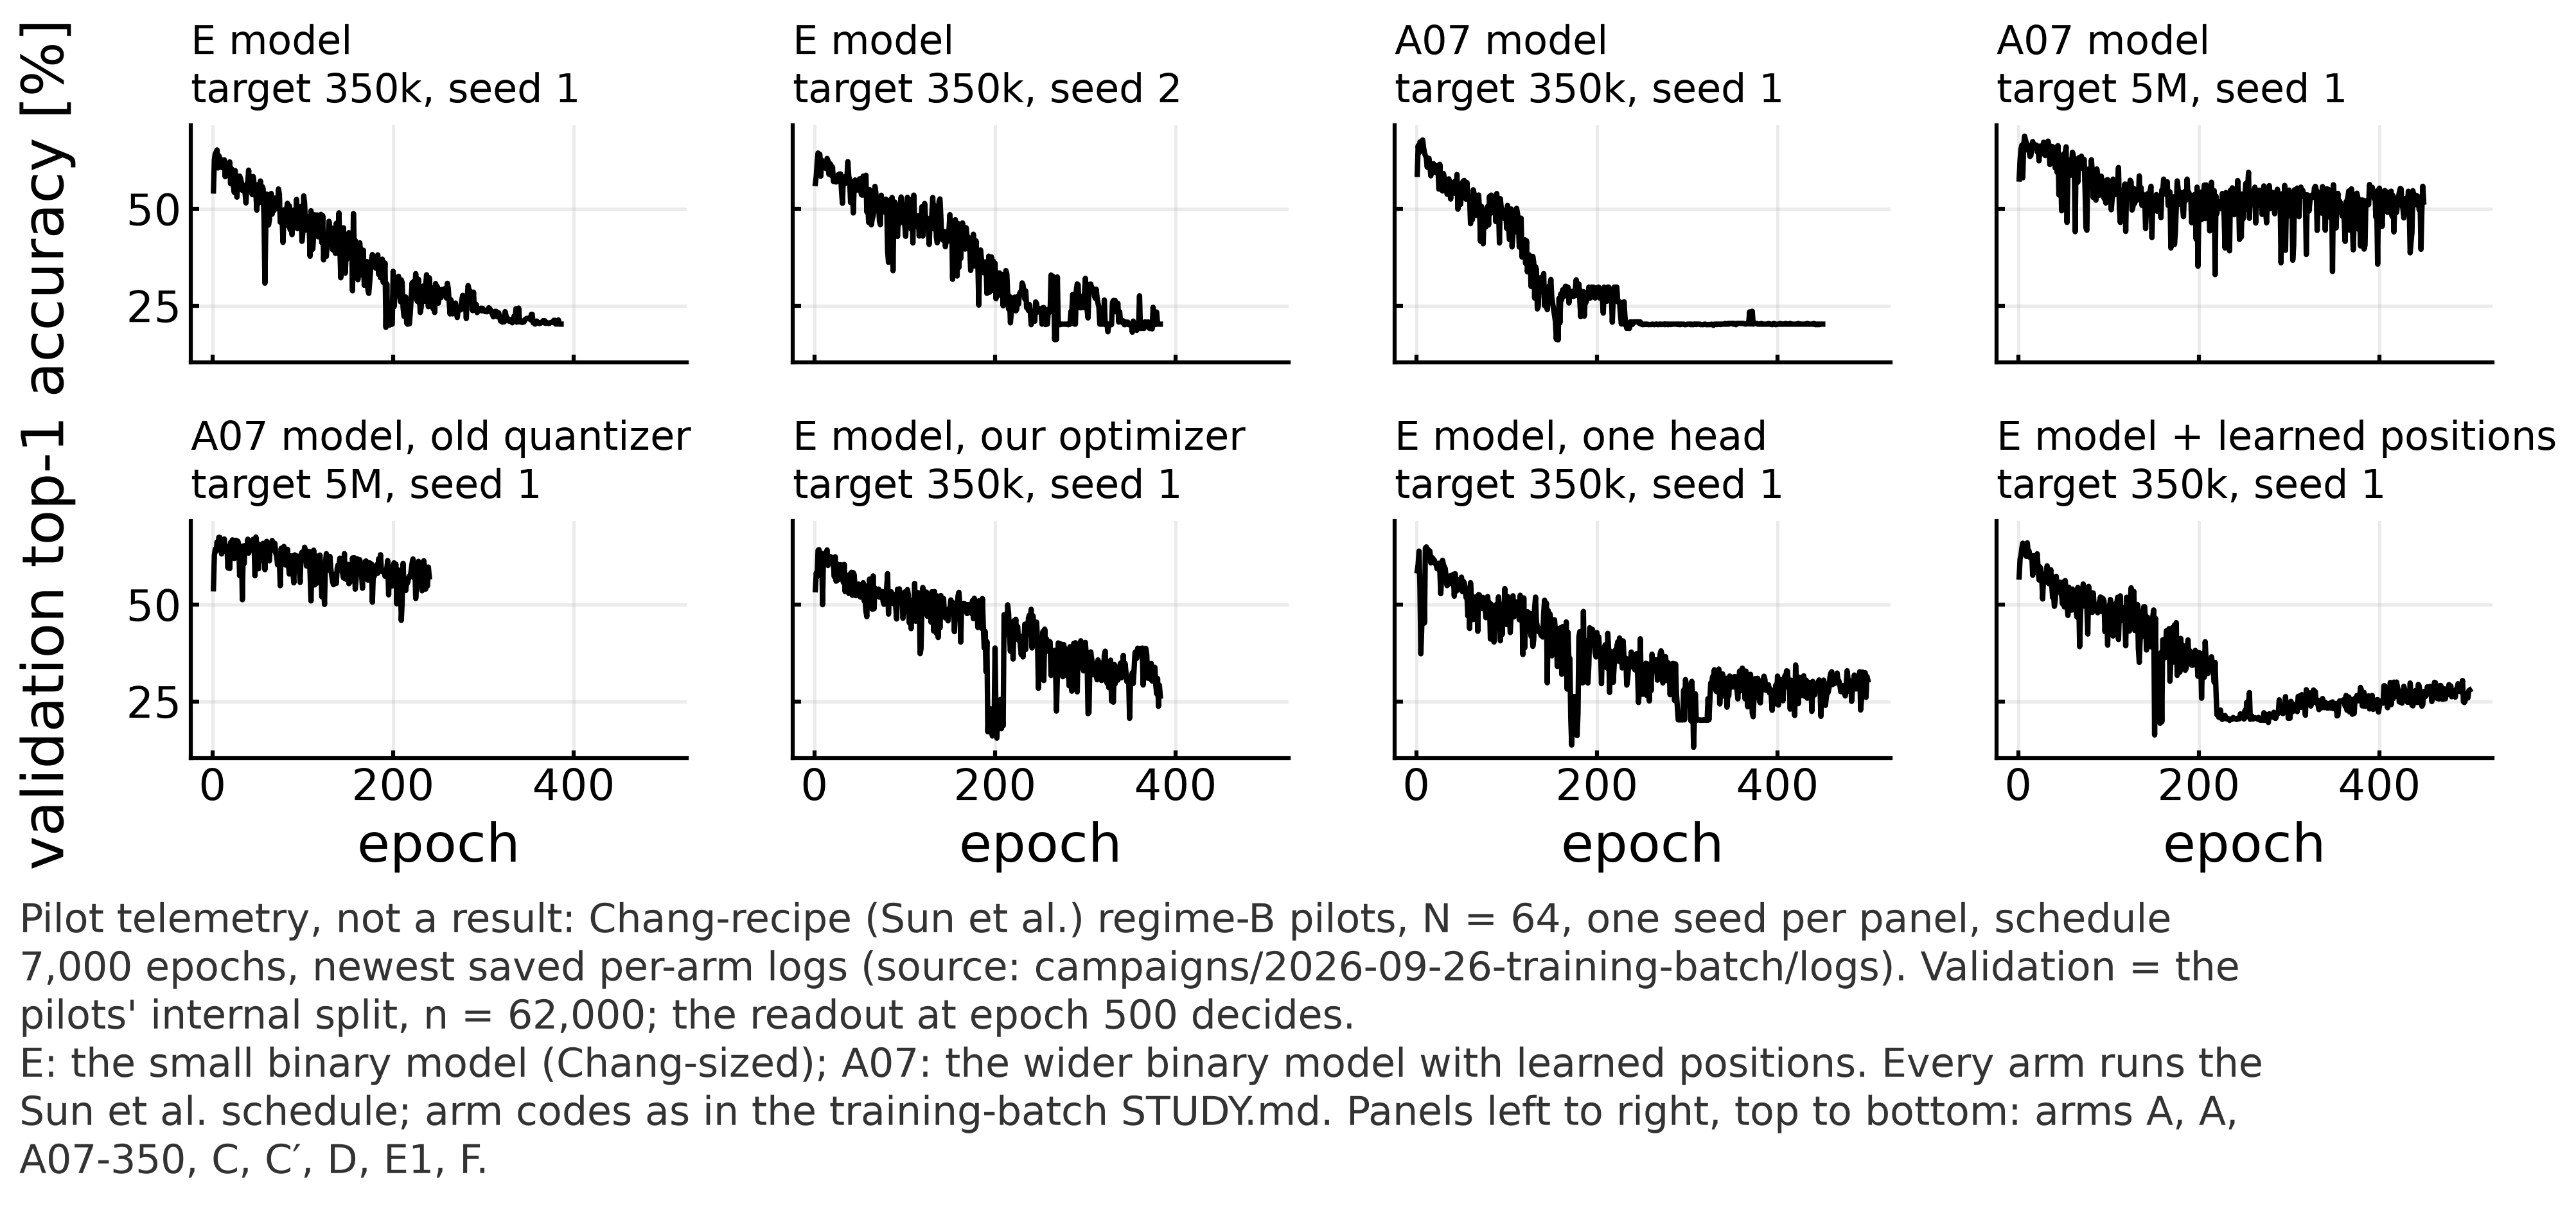

**Figure 8.** Pilot telemetry, not a result: validation top-1 accuracy (n = 62,000) per epoch. Peaks run from 64.20 % to 68.78 % and the last logged values from 20.26 % to 57.18 %; the last value is below the arm's own peak in 8 of 8 arms. At each arm's peak epoch its EBOPs were 1.3 to 26.1 times its target, so the peaks are not results at the target.

In [16]:
png = H.fig_chang(ch, "valacc")
peaks = [np.nanmax(a["val_acc"]) for a in ch["arms"]]
lasts = [a["val_acc"][-1] for a in ch["arms"]]
below = sum(l < p for l, p in zip(lasts, peaks))
ratios = []
for a in ch["arms"]:
    i = int(np.nanargmax(a["val_acc"]))
    e = a["traced"][i] if not np.isnan(a["traced"][i]) else a["in_training"][i]
    if a["target"] and not np.isnan(e):
        ratios.append(e / a["target"])
show(png, f"**Figure 8.** Pilot telemetry, not a result: validation top-1 accuracy (n = {ch['n_val']:,}) per epoch. "
          f"Peaks run from {H.pct(min(peaks))} to {H.pct(max(peaks))} and the last logged values from {H.pct(min(lasts))} "
          f"to {H.pct(max(lasts))}; the last value is below the arm's own peak in {below} of {len(ch['arms'])} arms. "
          + (f"At each arm's peak epoch its EBOPs were {min(ratios):.1f} to {max(ratios):.1f} times its target, so the "
             "peaks are not results at the target." if ratios else ""))

## 6. Infrastructure telemetry: GPU benchmark and the Delta memory canary

Scheduling and memory measurements for planning the next training waves. Nothing here is a
physics result.

**Benchmark telemetry, provisional.** Parsed from the `PHASE_DONE` lines of the saved pod logs. Arm-epochs per hour = K × epochs / wall time, start-up included; it is arithmetic on logged values, not a projection.

| product | Job | phase | model | K (arms per GPU) | wall time (s) | epochs per arm | arms ok | steady cores per arm | arm-epochs per hour |
|---|---|---|---|---|---|---|---|---|---|
| NVIDIA-A10 | kai-gpubench-a10-klow | p3-E-k3 | E (small binary model) | 3 | 1,880.3 | 21 | 3 / 3 | 0.575 | 121 |
| NVIDIA-A10 | kai-gpubench-a10-klow | p4-A07-k1 | A07 (wider binary model) | 1 | 1,180.1 | 21 | 1 / 1 | 0.588 | 64 |
| NVIDIA-A10 | kai-gpubench-a10-krule | p1-E-k4 | E (small binary model) | 4 | 2,530.5 | 21 | 4 / 4 | 0.556 | 120 |
| NVIDIA-A10 | kai-gpubench-a10-krule | p2-A07-k2 | A07 (wider binary model) | 2 | 2,235.3 | 21 | 2 / 2 | 0.543 | 68 |
| NVIDIA-A100-SXM4-80GB | kai-gpubench-a100-sxm4-80gb-krule | p1-E-k16 | E (small binary model) | 16 | 3,902.7 | 21 | 16 / 16 | 0.520 | 310 |
| NVIDIA-A100-SXM4-80GB | kai-gpubench-a100-sxm4-80gb-krule | p2-A07-k8 | A07 (wider binary model) | 8 | 3,181.5 | 21 | 8 / 8 | 0.544 | 190 |
| NVIDIA-GeForce-RTX-3090 | kai-gpubench-geforce-rtx-3090-klow | p3-E-k4 | E (small binary model) | 4 | 1,575.4 | 21 | 4 / 4 | 0.543 | 192 |
| NVIDIA-GeForce-RTX-3090 | kai-gpubench-geforce-rtx-3090-klow | p4-A07-k1 | A07 (wider binary model) | 1 | 815.1 | 21 | 1 / 1 | 0.623 | 93 |
| NVIDIA-GeForce-RTX-3090 | kai-gpubench-geforce-rtx-3090-krule | p1-E-k5 | E (small binary model) | 5 | 1,885.5 | 21 | 5 / 5 | 0.511 | 200 |
| NVIDIA-GeForce-RTX-3090 | kai-gpubench-geforce-rtx-3090-krule | p2-A07-k2 | A07 (wider binary model) | 2 | 1,330.2 | 21 | 2 / 2 | 0.534 | 114 |
| NVIDIA-GeForce-RTX-4090 | kai-gpubench-geforce-rtx-4090-klow | p3-E-k4 | E (small binary model) | 4 | 1,260.4 | 21 | 4 / 4 | 0.606 | 240 |
| NVIDIA-GeForce-RTX-4090 | kai-gpubench-geforce-rtx-4090-klow | p4-A07-k1 | A07 (wider binary model) | 1 | 715.1 | 21 | 1 / 1 | 0.667 | 106 |
| NVIDIA-GeForce-RTX-4090 | kai-gpubench-geforce-rtx-4090-krule | p1-E-k5 | E (small binary model) | 5 | 1,515.4 | 21 | 5 / 5 | 0.586 | 249 |
| NVIDIA-GeForce-RTX-4090 | kai-gpubench-geforce-rtx-4090-krule | p2-A07-k2 | A07 (wider binary model) | 2 | 1,180.2 | 21 | 2 / 2 | 0.593 | 128 |
| NVIDIA-RTX-A6000 | kai-gpubench-rtx-a6000-klow | p3-E-k4 | E (small binary model) | 4 | 1,715.5 | 21 | 4 / 4 | 0.512 | 176 |
| NVIDIA-RTX-A6000 | kai-gpubench-rtx-a6000-klow | p4-A07-k2 | A07 (wider binary model) | 2 | 1,515.3 | 21 | 2 / 2 | 0.525 | 100 |

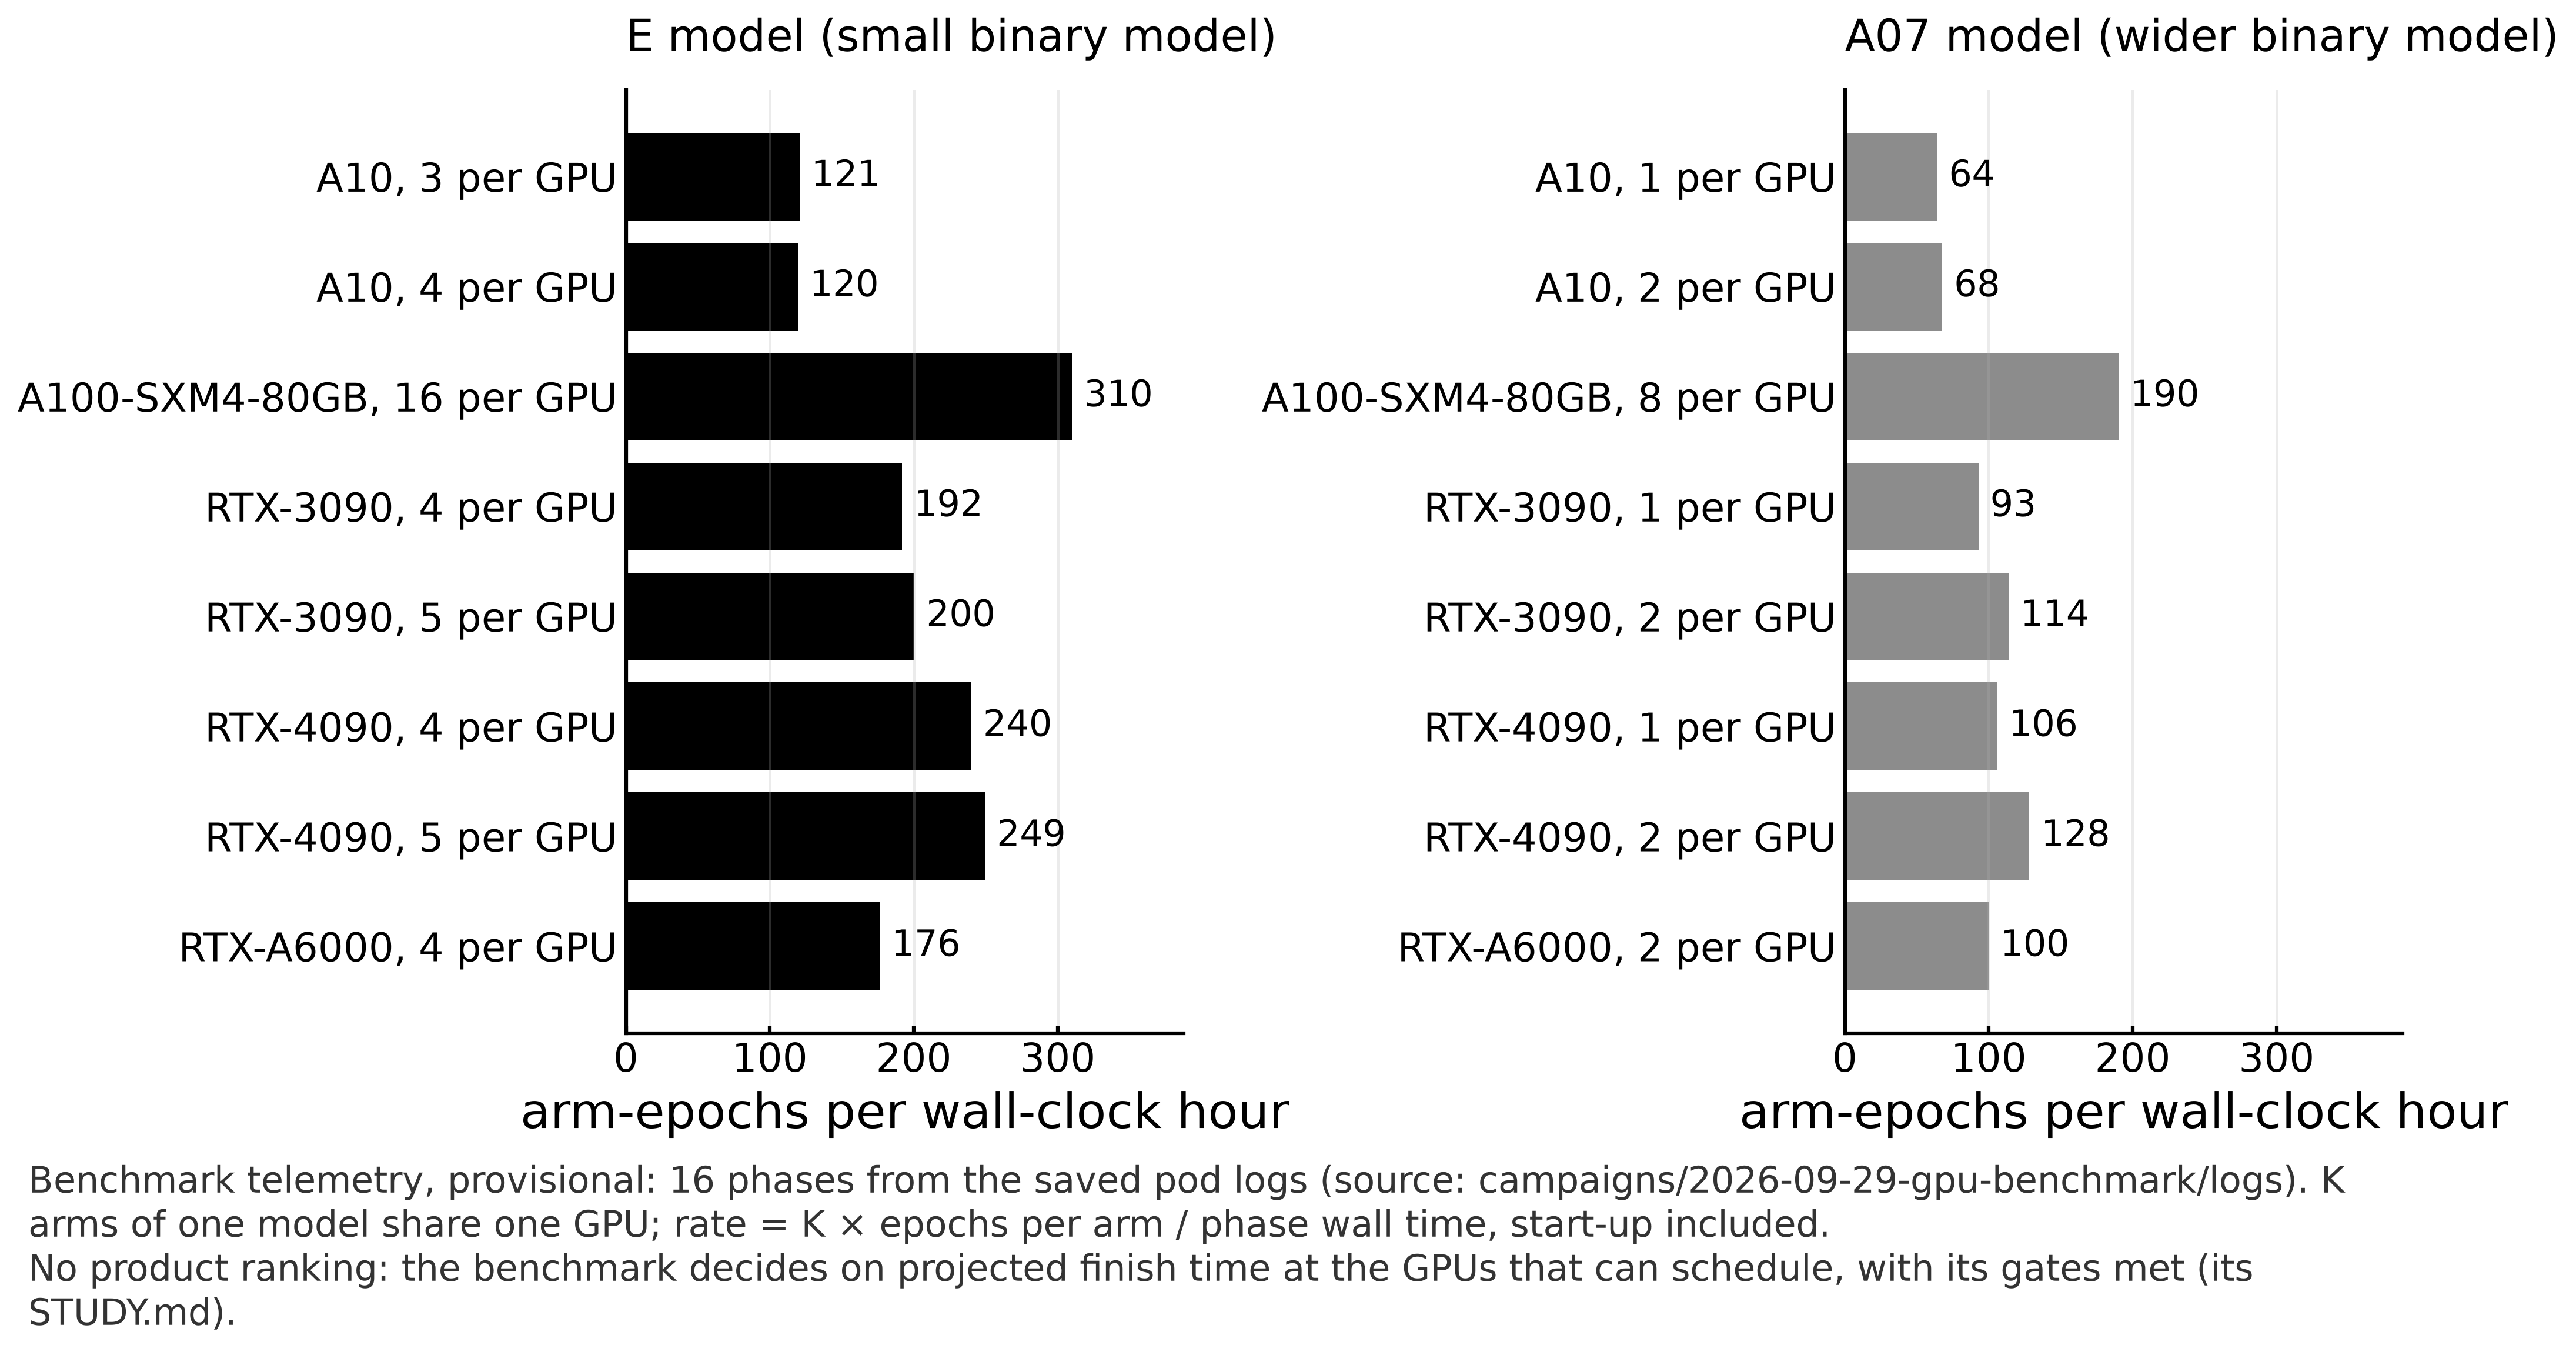

**Figure 9.** Benchmark telemetry, provisional: arm-epochs per wall-clock hour (K arms × epochs per arm / phase wall time, start-up included) for each of the 16 completed phases: the small E model on the left, the wider A07 model on the right. The benchmark decides on the projected finish time at the GPUs that can actually schedule, with its memory and utilization gates met (its STUDY.md), not on this per-GPU rate, so the figure ranks nothing.

In [17]:
plain_cls = {"E": "E (small binary model)", "A07": "A07 (wider binary model)"}
tab = [[r["product"], r["job"], r["phase"], plain_cls.get(r["cls"], r["cls"]), r["k"], f"{r['wall']:,.1f}", r["epochs"], f"{r['ok']} / {r['k']}",
        f"{r['cores_per_arm']:.3f}", f"{r['arm_epochs_per_h']:.0f}"] for r in bench]
md("**Benchmark telemetry, provisional.** Parsed from the `PHASE_DONE` lines of the saved pod logs. Arm-epochs per "
   "hour = K × epochs / wall time, start-up included; it is arithmetic on logged values, not a projection.")
md(H.md_table(["product", "Job", "phase", "model", "K (arms per GPU)", "wall time (s)", "epochs per arm", "arms ok",
               "steady cores per arm", "arm-epochs per hour"], tab))
png = H.fig_bench(bench)
show(png, f"**Figure 9.** Benchmark telemetry, provisional: arm-epochs per wall-clock hour (K arms × epochs per arm / "
          f"phase wall time, start-up included) for each of the {len(bench)} completed phases: the small E model on the "
          "left, the wider A07 model on the right. The benchmark decides on the projected finish time at the GPUs that can actually schedule, "
          "with its memory and utilization gates met (its STUDY.md), not on this per-GPU rate, so the figure ranks nothing.")

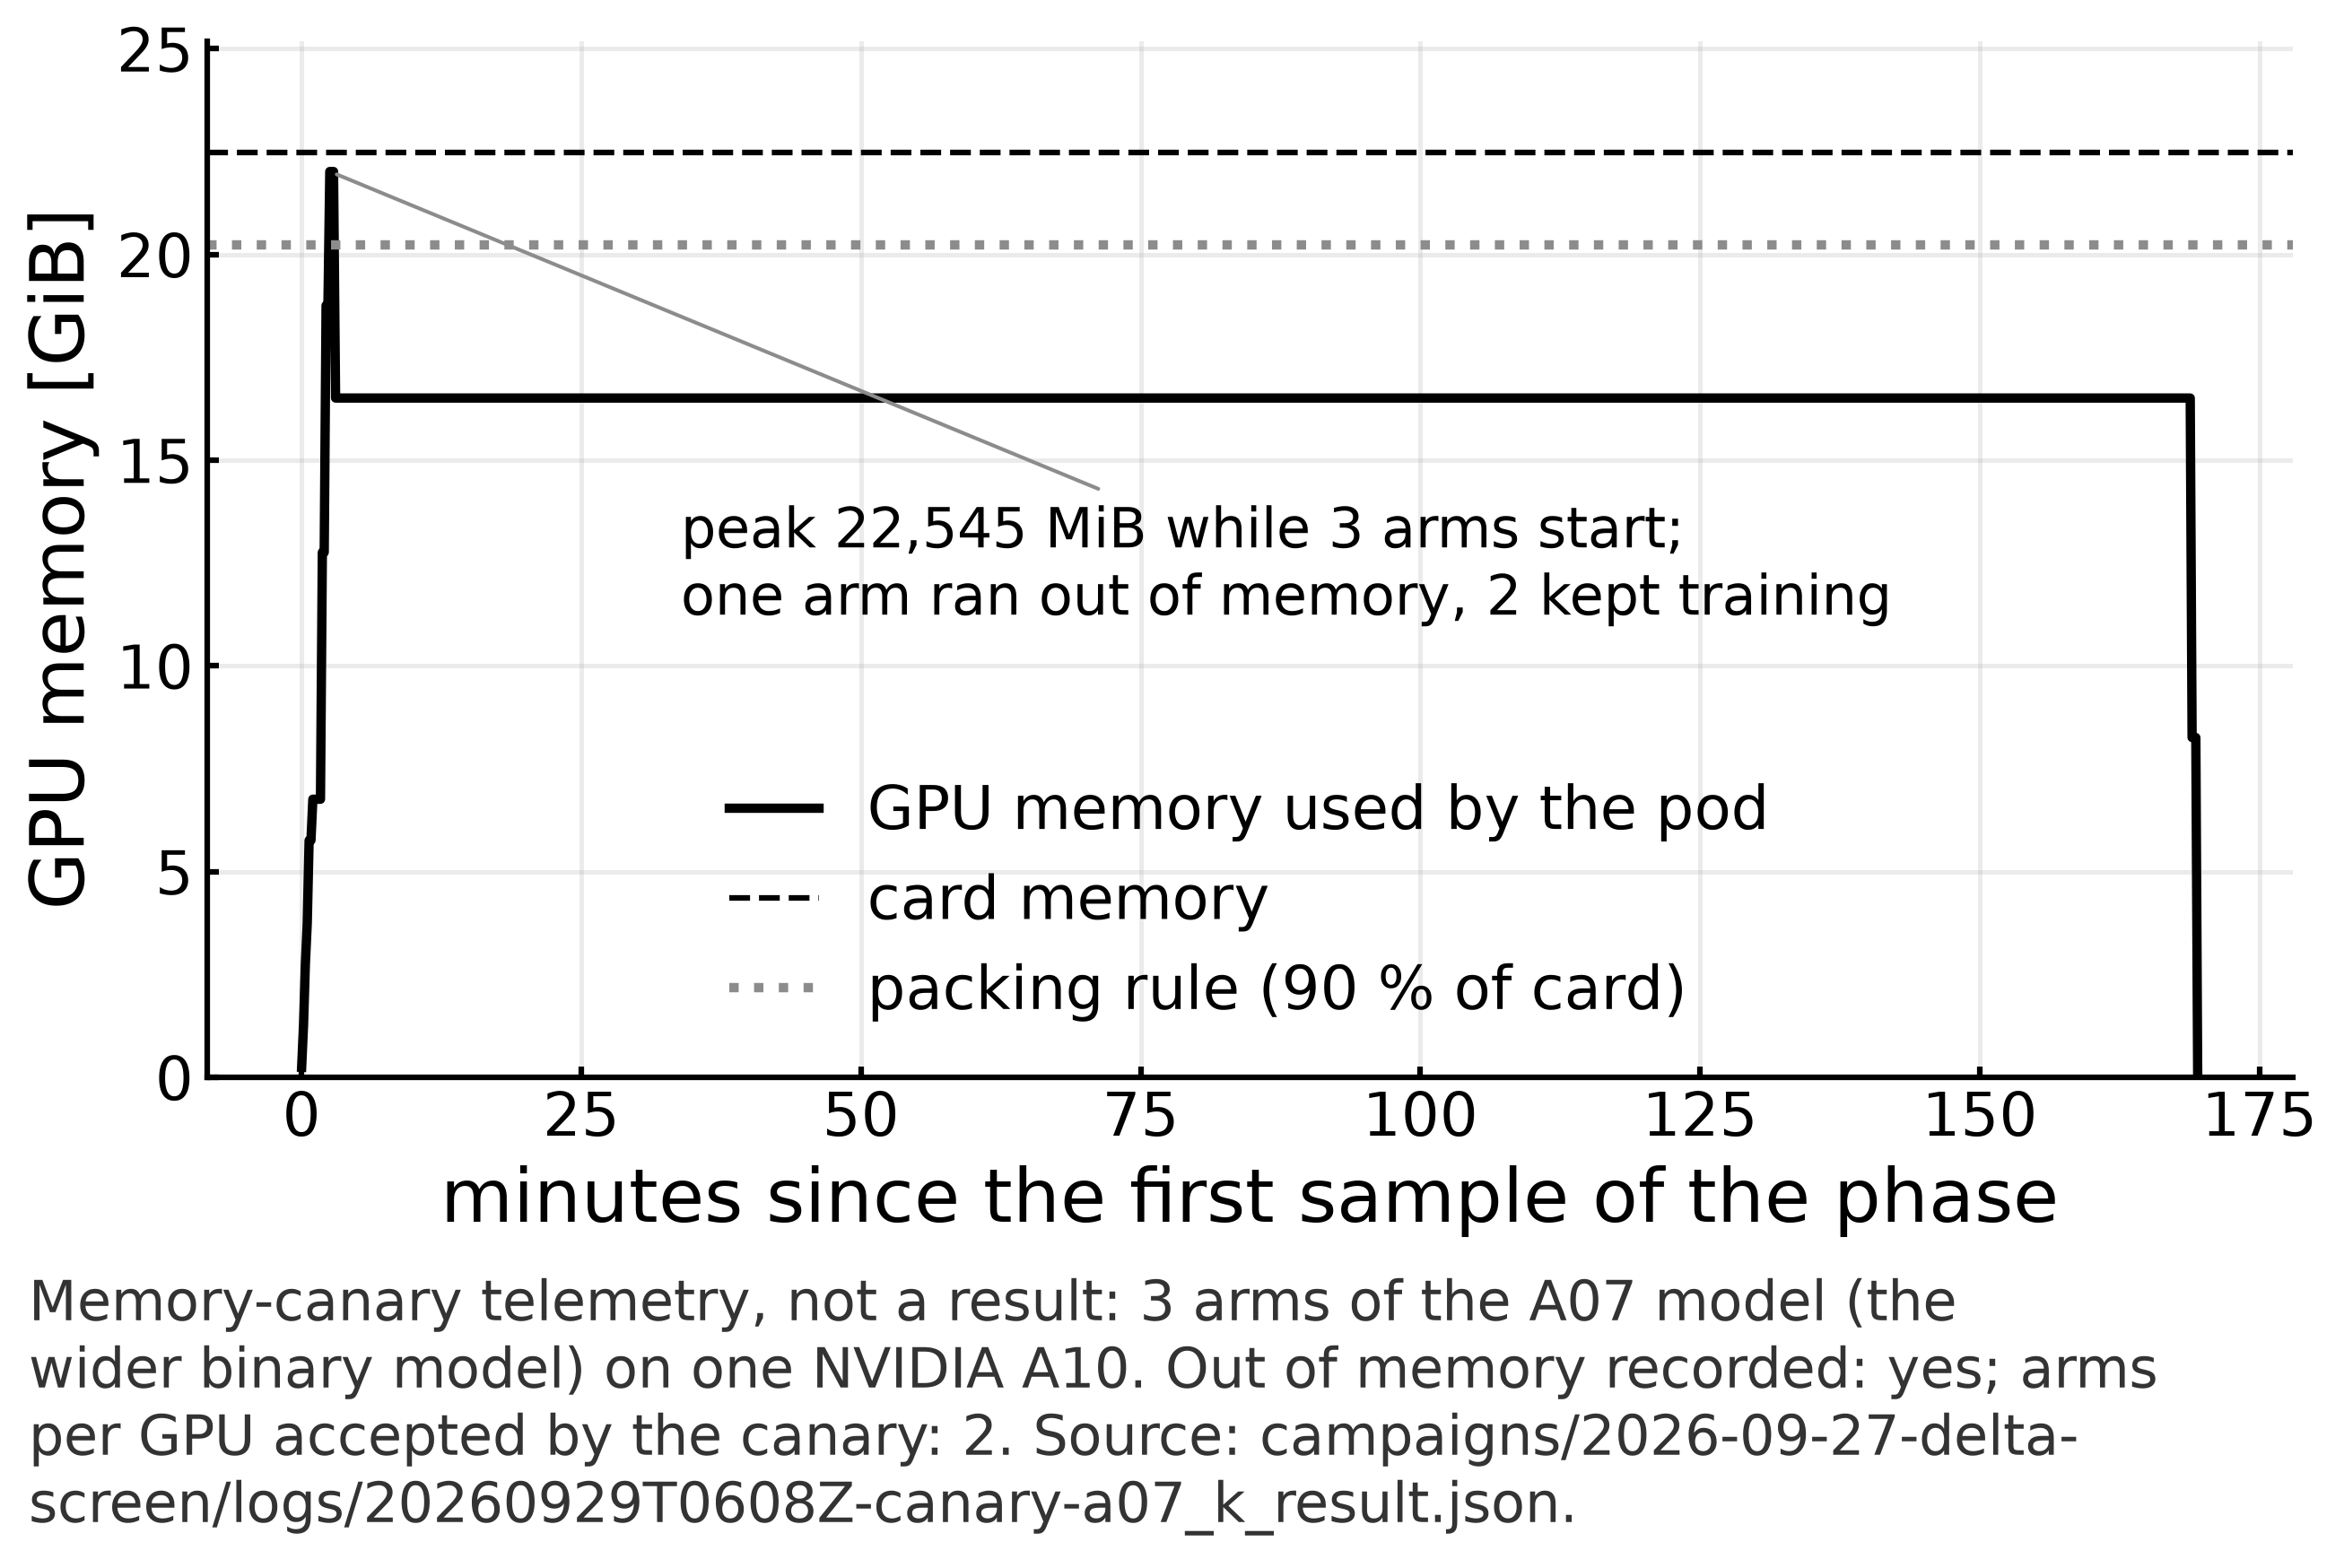

**Figure 10.** Memory-canary telemetry, not a result: GPU memory used by the pod while 3 arms of the A07 model start on one NVIDIA A10 (23,028 MiB). The pod peaked at 22,545 MiB (97.9 % of the card), one arm ran out of memory at start, and the two survivors held 8,446 MiB each. The canary accepted 2 arms per GPU for this model on this card.

In [18]:
png = H.fig_delta_memory(dc)
if png:
    show(png, f"**Figure 10.** Memory-canary telemetry, not a result: GPU memory used by the pod while "
              f"{k3.get('k_tested')} arms of the A07 model start on one {', '.join(k3.get('gpu_product', []))} "
              f"({k3.get('card_mib', 0):,.0f} MiB). The pod peaked at {k3.get('pod_peak_mib', 0):,.0f} MiB "
              f"({100 * k3.get('pod_peak_over_card', 0):.1f} % of the card), one arm ran out of memory at start, and the two "
              f"survivors held {k3.get('per_process_peak_mib', 0):,.0f} MiB each. The canary accepted "
              f"{k3.get('k_accepted')} arms per GPU for this model on this card.")

## 7. Archived context: Round 14 tagging performance (no EBOP target)

The pre-conference fixed-precision study: inputs (pt, etarel, phirel) at four constituent
counts, three seeds per variant, no cost constraint. It is the reference behind the silicon in
section 3 and is not comparable with the EBOP-constrained runs.

In [19]:
r14 = H.load_r14()
per = r14["per"]
tab = []
for N in H.R14_NS:
    fp = np.array([per[(N, "FP32", s)]["auc"] for s in (1, 2, 3)])
    for v in H.R14_VARIANTS:
        a = np.array([per[(N, v, s)]["auc"] for s in (1, 2, 3)])
        acc = np.array([per[(N, v, s)]["acc"] for s in (1, 2, 3)])
        cl = r14["claims"][N].get(v)
        ok = cl is not None and abs(round(a.mean(), 4) - cl[0]) < 1e-9 and abs(round(a.std(ddof=1), 4) - cl[1]) < 1e-9
        gap = H.t_interval(a - fp) if v != "FP32" else None
        tab.append([N, v, f"{a.mean():.4f} ± {a.std(ddof=1):.4f}", H.pct(acc.mean()),
                    f"{gap['mean']:+.4f} [{gap['lo']:+.4f}, {gap['hi']:+.4f}]" if gap else "reference",
                    "✓" if ok else f"✗ stored {cl}"])
n_r = per[(8, "FP32", 1)]["n"]
md(f"**Archived, recomputed here** from `{H.R14}/n<N>/*.npz`: held-out (ROC-test) split, n = {n_r:,}, mean ± sd over 3 seeds. The "
   "gap to FP32 is paired by seed with a 95 % t-interval (df 2); with three seeds these intervals are wide. The last "
   "column checks the stored `roc_auc.md` value at four decimals. Rows with different N are separate setups, "
   "not a trend.")
md(H.md_table(["N", "variant", "held-out (ROC-test) macro-OvR AUC (3 seeds)",
               "held-out (ROC-test) top-1 accuracy (3-seed mean)",
               "Δ AUC vs FP32, paired (95 % t)", "stored value"], tab))

**Archived, recomputed here** from `bnjettag/roc-results/r14/n<N>/*.npz`: held-out (ROC-test) split, n = 260,000, mean ± sd over 3 seeds. The gap to FP32 is paired by seed with a 95 % t-interval (df 2); with three seeds these intervals are wide. The last column checks the stored `roc_auc.md` value at four decimals. Rows with different N are separate setups, not a trend.

| N | variant | held-out (ROC-test) macro-OvR AUC (3 seeds) | held-out (ROC-test) top-1 accuracy (3-seed mean) | Δ AUC vs FP32, paired (95 % t) | stored value |
|---|---|---|---|---|---|
| 8 | FP32 | 0.8864 ± 0.0005 | 64.63 % | reference | ✓ |
| 8 | W8A8 | 0.8862 ± 0.0009 | 64.48 % | -0.0002 [-0.0013, +0.0009] | ✓ |
| 8 | W1A8 | 0.8712 ± 0.0016 | 62.24 % | -0.0152 [-0.0201, -0.0103] | ✓ |
| 8 | W1A6 | 0.8689 ± 0.0020 | 61.90 % | -0.0175 [-0.0235, -0.0116] | ✓ |
| 8 | W1A4 | 0.8534 ± 0.0012 | 58.48 % | -0.0331 [-0.0365, -0.0296] | ✓ |
| 16 | FP32 | 0.9128 ± 0.0013 | 70.50 % | reference | ✓ |
| 16 | W8A8 | 0.9124 ± 0.0014 | 70.26 % | -0.0004 [-0.0019, +0.0011] | ✓ |
| 16 | W1A8 | 0.8956 ± 0.0002 | 67.52 % | -0.0172 [-0.0199, -0.0144] | ✓ |
| 16 | W1A6 | 0.8910 ± 0.0009 | 66.44 % | -0.0217 [-0.0227, -0.0208] | ✓ |
| 16 | W1A4 | 0.8693 ± 0.0021 | 61.46 % | -0.0435 [-0.0466, -0.0403] | ✓ |
| 32 | FP32 | 0.9374 ± 0.0017 | 76.06 % | reference | ✓ |
| 32 | W8A8 | 0.9358 ± 0.0011 | 75.61 % | -0.0016 [-0.0035, +0.0002] | ✓ |
| 32 | W1A8 | 0.9052 ± 0.0079 | 68.41 % | -0.0322 [-0.0495, -0.0149] | ✓ |
| 32 | W1A6 | 0.9022 ± 0.0009 | 68.01 % | -0.0352 [-0.0371, -0.0333] | ✓ |
| 32 | W1A4 | 0.8833 ± 0.0013 | 63.93 % | -0.0541 [-0.0601, -0.0481] | ✓ |
| 64 | FP32 | 0.9486 ± 0.0012 | 79.11 % | reference | ✓ |
| 64 | W8A8 | 0.9448 ± 0.0011 | 77.52 % | -0.0038 [-0.0095, +0.0018] | ✓ |
| 64 | W1A8 | 0.9121 ± 0.0116 | 69.01 % | -0.0365 [-0.0676, -0.0054] | ✓ |
| 64 | W1A6 | 0.9136 ± 0.0061 | 69.84 % | -0.0350 [-0.0531, -0.0168] | ✓ |
| 64 | W1A4 | 0.9073 ± 0.0009 | 67.91 % | -0.0413 [-0.0463, -0.0363] | ✓ |

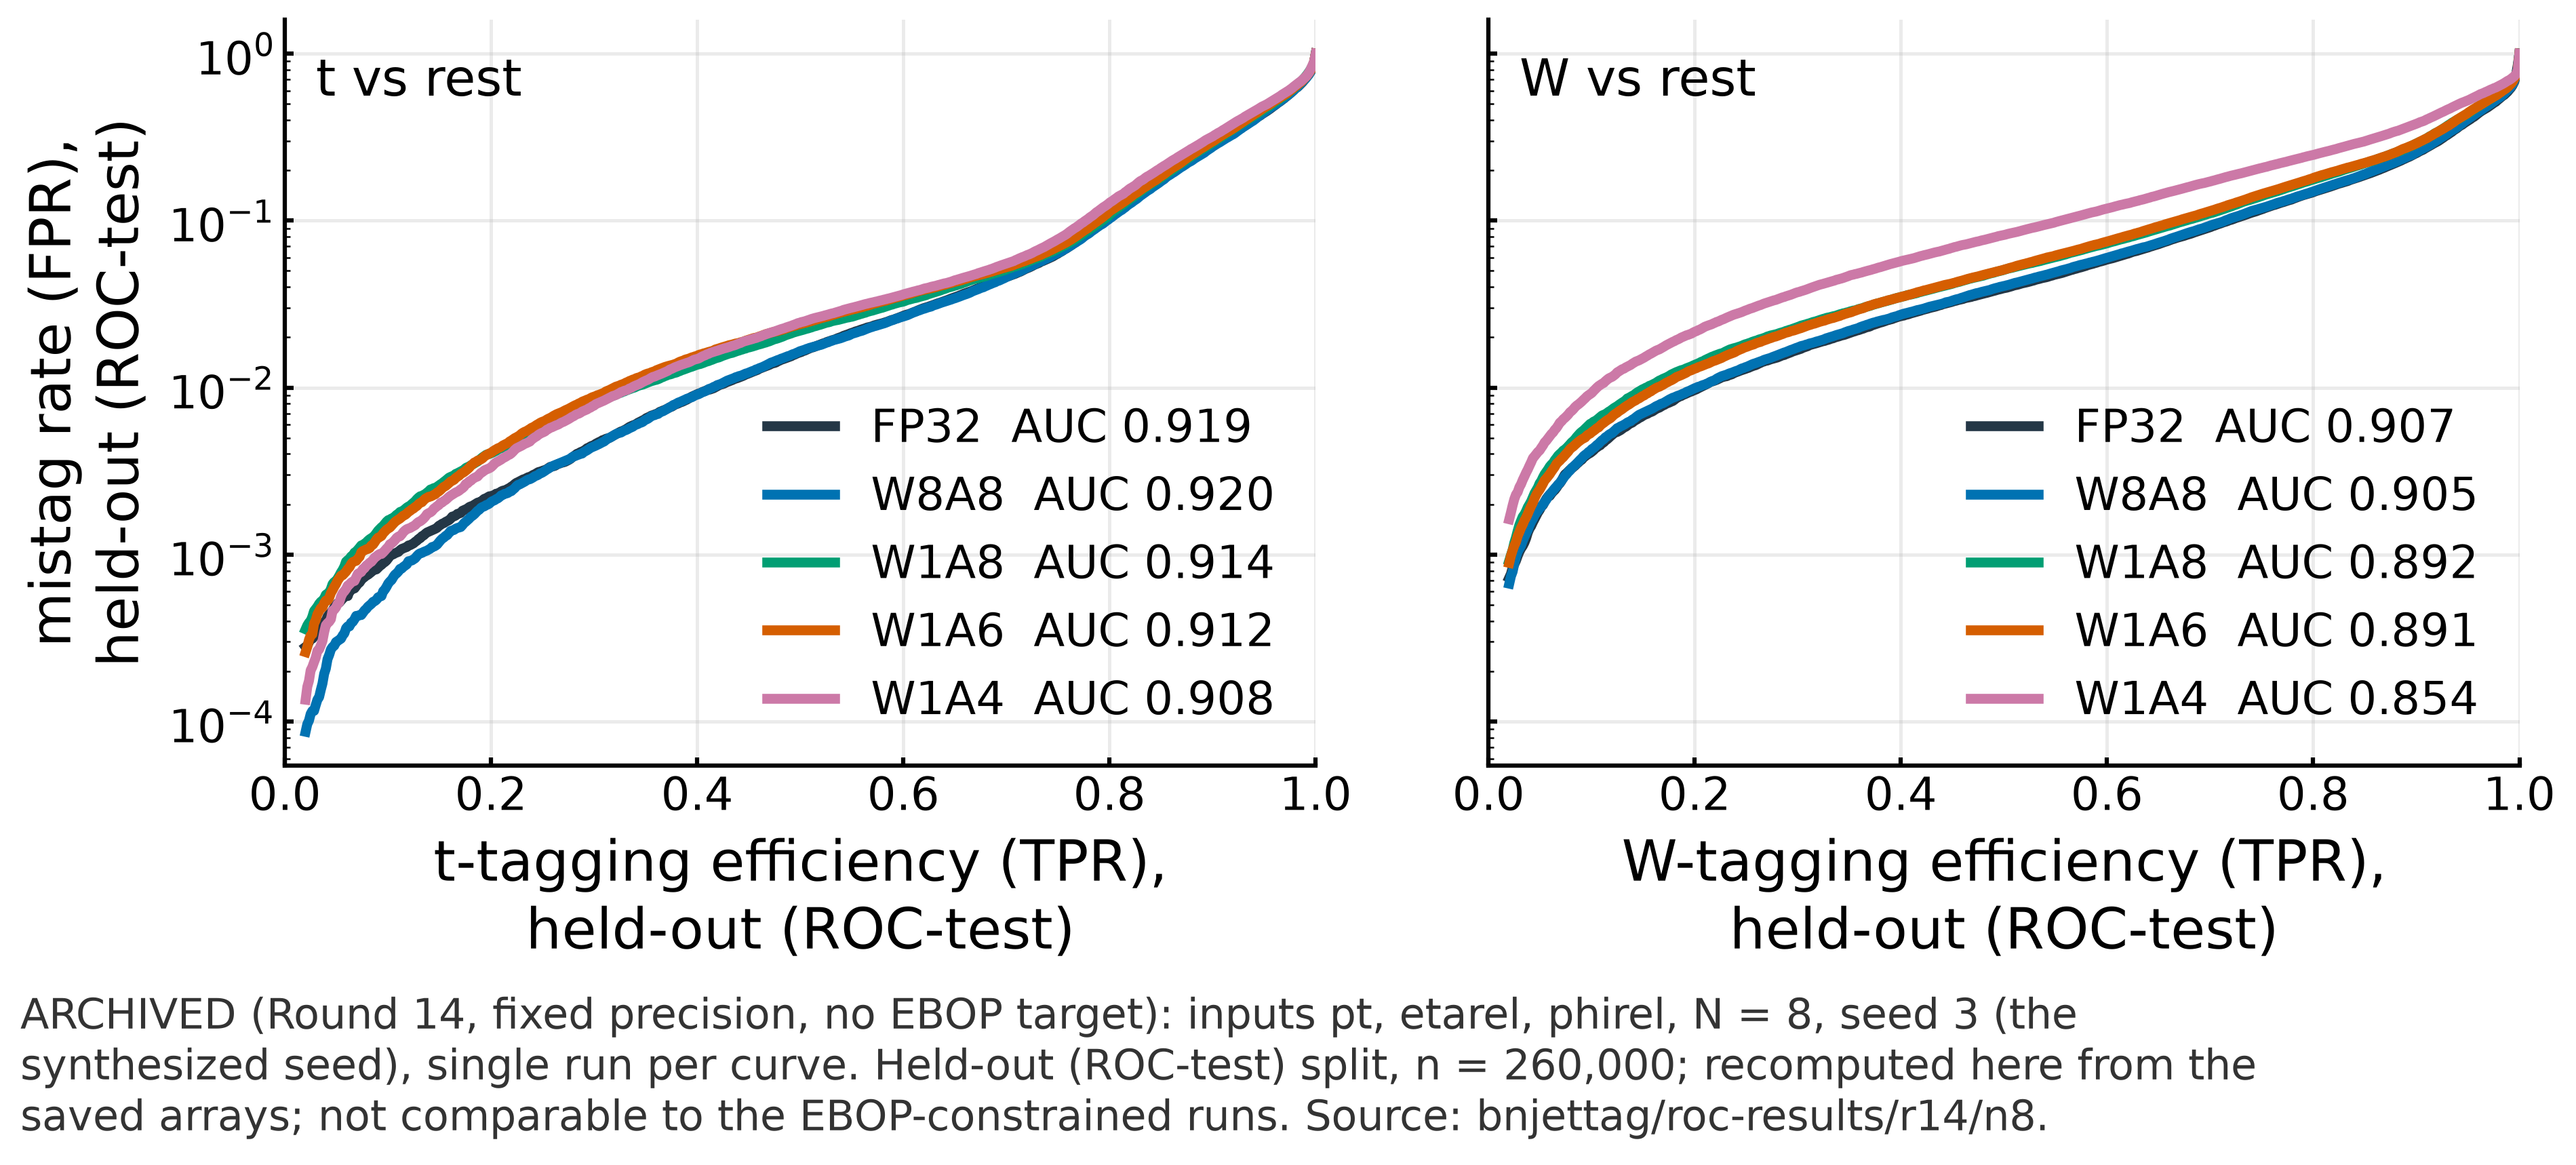

**Figure 11.** Archived Round-14 ROC curves at N = 8, seed 3 (the synthesized seed), held-out (ROC-test) split, n = 260,000, mistag rate on a log axis. For top-quark tagging the five variants sit close together (FP32 AUC 0.919, W1A8 0.914); for W tagging, 4-bit activations cost the most (FP32 0.907, W1A4 0.854). Single seed per curve; the macro-AUC seed spread is in the table above.

In [20]:
png = H.fig_r14_roc(r14)
def cls_auc(v, c):
    y, sc = r14["roc"][v]
    from sklearn.metrics import roc_auc_score
    i = H.CLASSES.index(c)
    return roc_auc_score(y[:, i], sc[:, i])
w_fp, w_a4 = cls_auc("FP32", "W"), cls_auc("W1A4", "W")
t_fp, t_a8 = cls_auc("FP32", "t"), cls_auc("W1A8", "t")
show(png, f"**Figure 11.** Archived Round-14 ROC curves at N = {r14['roc_n']}, seed {r14['roc_seed']} (the synthesized "
          f"seed), held-out (ROC-test) split, n = {n_r:,}, mistag rate on a log axis. For top-quark tagging the five variants sit "
          f"close together (FP32 AUC {t_fp:.3f}, W1A8 {t_a8:.3f}); for W tagging, 4-bit activations cost the most "
          f"(FP32 {w_fp:.3f}, W1A4 {w_a4:.3f}). Single seed per curve; the macro-AUC seed spread is in the table above.")

## 8. Not included, and caveats in the sources

- Current-era N = 64 results at the 5M EBOPs target: the confirmation queue's N = 64 runs have no saved evaluation on this machine.
- Seed-confirmation runs for the N = 8 architecture arms (seeds 2 and 3): no final evaluation saved on this machine, so the reported A02 number has no seed spread.
- Any hardware number for a current-era model: the R4 gradual-budget synthesis stopped in the Vitis front end with no csynth report (`campaigns/2026-09-17-synthesis-r4-gradual/README.md`).
- Chang-recipe (Sun et al.) results, the A − NB and A − FP32-E comparisons, and the distance to the published Deep Sets row: no readout of the pilots is saved.
- Delta wave-2 screen results: only the memory canary has run.
- The GPU benchmark's verdict: no summary or VERIFY.md is saved here; section 6 shows only the phases whose pod logs were copied.
- The standalone long-budget N = 8 run and the initial budget-control study: validation AUC quoted from training metadata, no held-out evaluation saved.
- Engram studies: the selected-checkpoint metrics of E01–E03 did not reproduce, and no memory-versus-control gain is quotable.
- Vivado place-and-route, timing closure on the VU13P and on-board latency: never run; section 3 is pre-route and out of context.

In [21]:
lines = []
for r in [r for r in cur["rows"] if not r["missing"] and r["interim"]]:
    sf = r["status_file"] or (None, None)
    lines.append(f"- **{H.ARM_NAMES.get(r['arm'], r['arm'])}**: `{H.ABL_DIR}/manifest.json` records the evaluated checkpoint as `complete: "
                 f"{r['manifest_complete']}` after {r['snapshot_epochs']:,} epochs, while `{H.ABL_JSON}` records the same arm "
                 f"as `status: {r['json_status']}`. `{H.ABL_STATUS}` lists the arm as `{sf[0]}` at "
                 f"{sf[1]:,} epochs. The "
                 "figures and tables mark this arm as selected from an interim snapshot; the difference is not resolved here.")
if cur["train_done_date"] and str(cur["eval_date"]) < str(cur["train_done_date"]):
    lines.append(f"- `{H.ABL_JSON}` gives `evaluation_date` {cur['eval_date']}, earlier than its own "
                 f"`training_completion_date` {cur['train_done_date']}. Not resolved here.")
md("**Caveats in the sources**, listed as found and not resolved:\n\n" + "\n".join(lines) if lines
   else "No inconsistency found between the ablation records.")

**Caveats in the sources**, listed as found and not resolved:

- **Knowledge distillation**: `campaigns/2026-09-16-accuracy-investigation/remote-results/manifest.json` records the evaluated checkpoint as `complete: False` after 898 epochs, while `publication/results/post_conference/ablation_metrics.json` records the same arm as `status: finished`. `publication/results/post_conference/ablation-training-status-20260920.json` lists the arm as `training_complete` at 1,000 epochs. The figures and tables mark this arm as selected from an interim snapshot; the difference is not resolved here.
- `publication/results/post_conference/ablation_metrics.json` gives `evaluation_date` 2026-09-16, earlier than its own `training_completion_date` 2026-09-20. Not resolved here.

## 9. Inputs of this run

Every file the notebook read, with its size and modification time, so a rerun can be checked
against this one (the pilot logs change as new copies are saved).

In [22]:
md(H.sources_table())
md(f"Notebook runtime: {time.time() - T0:.0f} s.")

| file read by this run | bytes | modified (local time) |
|---|---|---|
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-beta1sm4i0/csynth_beta1sm4i0/csynth_report.json` | 375 | 2026-08-19 16:55 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev/clock.xdc` | 59 | 2026-08-22 13:56 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev/post_opt_timing.rpt` | 56,655 | 2026-08-22 20:38 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev/post_opt_util.rpt` | 8,922 | 2026-08-22 20:32 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev/vivado_run.log` | 3,449,311 | 2026-08-22 20:38 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev_5ns/clock.xdc` | 59 | 2026-08-22 21:31 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev_5ns/post_opt_timing.rpt` | 56,665 | 2026-08-23 04:19 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev_5ns/post_opt_util.rpt` | 8,922 | 2026-08-23 04:13 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-beta1sm4i0/postsyn_xczu7ev_5ns/vivado_run.log` | 3,449,640 | 2026-08-23 04:19 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-da13/csynth_da13/csynth_report.json` | 377 | 2026-08-14 14:59 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-pf1fab/csynth_pf1fab/csynth_report.json` | 375 | 2026-08-17 21:02 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-pf1fab/postsyn_xczu7ev/post_opt_timing.rpt` | 56,635 | 2026-08-18 13:31 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-pf1fab/postsyn_xczu7ev/post_opt_util.rpt` | 8,922 | 2026-08-18 04:35 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-pf1fab/postsyn_xczu7ev/synth_ooc.tcl` | 629 | 2026-08-18 04:35 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-pf1scoped/csynth_pf1scoped/csynth_report.json` | 375 | 2026-08-18 22:25 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-pf1scoped/postsyn_xczu7ev/clock.xdc` | 59 | 2026-08-19 11:14 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-pf1scoped/postsyn_xczu7ev/post_opt_timing.rpt` | 59,000 | 2026-08-19 11:17 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-pf1scoped/postsyn_xczu7ev/post_opt_util.rpt` | 9,065 | 2026-08-19 11:14 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-pf1scoped/postsyn_xczu7ev/vivado_run.log` | 7,907,901 | 2026-08-19 11:18 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-pf1sm1df/csynth_pf1sm1df/csynth_report.json` | 378 | 2026-08-12 00:38 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-pf2sm2df/csynth_pf2sm2df/csynth_report.json` | 378 | 2026-08-11 14:14 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8-relufix/csynth_relufix/csynth_report.json` | 377 | 2026-08-16 00:39 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/csynth_rf1/csynth_report.json` | 377 | 2026-08-04 05:07 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/csynth_rf1_fabric/csynth_report.json` | 374 | 2026-08-04 07:25 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev/post_synth_timing.rpt` | 59,334 | 2026-08-14 17:05 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev/post_synth_util.rpt` | 9,024 | 2026-08-14 17:05 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev/synth_ooc.tcl` | 771 | 2026-08-14 17:05 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev/vivado_log_excerpt_dsp_demand.txt` | 1,332 | 2026-08-22 22:05 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev_fabric/post_synth_timing.rpt` | 52,399 | 2026-08-14 19:26 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev_fabric/post_synth_util.rpt` | 8,881 | 2026-08-14 19:26 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev_fabric/synth_ooc.tcl` | 615 | 2026-08-14 19:26 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev_fabric_v2/clock.xdc` | 59 | 2026-08-16 12:00 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev_fabric_v2/post_opt_timing.rpt` | 33,525 | 2026-08-16 12:07 |
| `bnjettag/results/synthesis/runs/38a20c62/w1a8-s3-r14n8/postsyn_xczu7ev_fabric_v2/post_opt_util.rpt` | 8,922 | 2026-08-16 12:00 |
| `bnjettag/results/synthesis/runs/40103802/fp32-s3-r14n8-w16/csynth_rf1/csynth_report.json` | 382 | 2026-09-03 08:51 |
| `bnjettag/results/synthesis/runs/40103802/fp32-s3-r14n8-w8/csynth_rf1/csynth_report.json` | 378 | 2026-09-03 08:52 |
| `bnjettag/results/synthesis/runs/5f839ab5/w1a4-s3/csynth_rf1/csynth_report.json` | 376 | 2026-08-13 14:36 |
| `bnjettag/results/synthesis/runs/794e925f/w1a6-s3/csynth_rf1/csynth_report.json` | 377 | 2026-08-13 17:00 |
| `bnjettag/results/synthesis/runs/9cc6e336/w8a8-s3-r14n8/csynth_rf1/csynth_report.json` | 377 | 2026-08-24 09:23 |
| `bnjettag/results/synthesis/runs/9cc6e336/w8a8-s3-r14n8/postsyn_xczu7ev/clock.xdc` | 59 | 2026-08-24 09:23 |
| `bnjettag/results/synthesis/runs/9cc6e336/w8a8-s3-r14n8/postsyn_xczu7ev/post_opt_timing.rpt` | 33,520 | 2026-08-24 16:53 |
| `bnjettag/results/synthesis/runs/9cc6e336/w8a8-s3-r14n8/postsyn_xczu7ev/post_opt_util.rpt` | 9,120 | 2026-08-24 16:42 |
| `bnjettag/results/synthesis/runs/9cc6e336/w8a8-s3-r14n8/postsyn_xczu7ev/vivado.jou` | 811 | 2026-08-24 09:24 |
| `bnjettag/results/synthesis/runs/9cc6e336/w8a8-s3-r14n8/postsyn_xczu7ev/vivado_log_excerpt_dsp_demand.txt` | 1,038 | 2026-08-24 17:43 |
| `bnjettag/results/synthesis/runs/9cc6e336/w8a8-s3-r14n8/postsyn_xczu7ev/vivado_run.log` | 6,535,349 | 2026-08-24 16:53 |
| `bnjettag/results/synthesis/runs/ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/csynth_pf1scoped/csynth_report.json` | 375 | 2026-08-23 14:44 |
| `bnjettag/results/synthesis/runs/ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev/clock.xdc` | 59 | 2026-08-23 14:46 |
| `bnjettag/results/synthesis/runs/ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev/post_opt_timing.rpt` | 56,767 | 2026-08-23 22:28 |
| `bnjettag/results/synthesis/runs/ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev/post_opt_util.rpt` | 8,922 | 2026-08-23 22:22 |
| `bnjettag/results/synthesis/runs/ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev/vivado_run.log` | 3,473,300 | 2026-08-23 22:28 |
| `bnjettag/results/synthesis/runs/ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev_5ns/clock.xdc` | 59 | 2026-08-23 22:29 |
| `bnjettag/results/synthesis/runs/ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev_5ns/post_opt_timing.rpt` | 56,777 | 2026-08-24 07:01 |
| `bnjettag/results/synthesis/runs/ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev_5ns/post_opt_util.rpt` | 8,922 | 2026-08-24 06:55 |
| `bnjettag/results/synthesis/runs/ba72a91a/w1a8-s3-r15gamma-sm4i0-pf1scoped/postsyn_xczu7ev_5ns/vivado_run.log` | 3,474,177 | 2026-08-24 07:02 |
| `bnjettag/roc-results/ptw-n8/BASE-s1.npz` | 5,890,833 | 2026-09-26 13:16 |
| `bnjettag/roc-results/ptw-n8/BASE-s2.npz` | 5,889,754 | 2026-09-26 13:17 |
| `bnjettag/roc-results/ptw-n8/BASE-s3.npz` | 5,889,863 | 2026-09-26 13:18 |
| `bnjettag/roc-results/ptw-n8/BASE-s4.npz` | 5,878,191 | 2026-09-26 13:19 |
| `bnjettag/roc-results/ptw-n8/BASE-s5.npz` | 5,888,248 | 2026-09-26 13:20 |
| `bnjettag/roc-results/ptw-n8/BASE-s6.npz` | 5,887,479 | 2026-09-26 13:21 |
| `bnjettag/roc-results/ptw-n8/BASE-s7.npz` | 5,887,881 | 2026-09-26 13:22 |
| `bnjettag/roc-results/ptw-n8/BASE-s8.npz` | 5,896,981 | 2026-09-26 13:23 |
| `bnjettag/roc-results/ptw-n8/PTW5-s1.npz` | 5,896,805 | 2026-09-26 13:16 |
| `bnjettag/roc-results/ptw-n8/PTW5-s2.npz` | 5,892,098 | 2026-09-26 13:17 |
| `bnjettag/roc-results/ptw-n8/PTW5-s3.npz` | 5,886,905 | 2026-09-26 13:18 |
| `bnjettag/roc-results/ptw-n8/PTW5-s4.npz` | 5,848,762 | 2026-09-26 13:19 |
| `bnjettag/roc-results/ptw-n8/PTW5-s5.npz` | 5,869,939 | 2026-09-26 13:21 |
| `bnjettag/roc-results/ptw-n8/PTW5-s6.npz` | 5,884,052 | 2026-09-26 13:22 |
| `bnjettag/roc-results/ptw-n8/PTW5-s7.npz` | 5,880,938 | 2026-09-26 13:23 |
| `bnjettag/roc-results/ptw-n8/PTW5-s8.npz` | 5,892,727 | 2026-09-26 13:24 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s1.npz` | 5,886,888 | 2026-09-26 13:17 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s2.npz` | 5,895,925 | 2026-09-26 13:18 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s3.npz` | 5,892,825 | 2026-09-26 13:19 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s4.npz` | 5,875,899 | 2026-09-26 13:20 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s5.npz` | 5,864,494 | 2026-09-26 13:21 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s6.npz` | 5,878,521 | 2026-09-26 13:22 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s7.npz` | 5,879,943 | 2026-09-26 13:23 |
| `bnjettag/roc-results/ptw-n8/PTWNC-s8.npz` | 5,891,607 | 2026-09-26 13:24 |
| `bnjettag/roc-results/ptw-n8/summary.json` | 107,999 | 2026-09-26 13:25 |
| `bnjettag/roc-results/r14/n16/FP32-s1.npz` | 5,066,912 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/FP32-s2.npz` | 5,066,717 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/FP32-s3.npz` | 5,059,350 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W1A4-s1.npz` | 4,705,679 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W1A4-s2.npz` | 4,849,367 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W1A4-s3.npz` | 4,741,655 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W1A6-s1.npz` | 5,027,908 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W1A6-s2.npz` | 5,025,033 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W1A6-s3.npz` | 5,013,210 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W1A8-s1.npz` | 5,017,307 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W1A8-s2.npz` | 5,041,017 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W1A8-s3.npz` | 5,004,861 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W8A8-s1.npz` | 5,061,434 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W8A8-s2.npz` | 5,063,505 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/W8A8-s3.npz` | 5,061,597 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n16/roc_auc.md` | 2,867 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/FP32-s1.npz` | 5,088,184 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/FP32-s2.npz` | 5,091,683 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/FP32-s3.npz` | 5,085,480 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W1A4-s1.npz` | 4,917,195 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W1A4-s2.npz` | 4,980,564 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W1A4-s3.npz` | 4,910,651 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W1A6-s1.npz` | 5,052,714 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W1A6-s2.npz` | 5,047,579 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W1A6-s3.npz` | 5,049,772 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W1A8-s1.npz` | 5,042,715 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W1A8-s2.npz` | 5,063,916 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W1A8-s3.npz` | 5,050,434 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W8A8-s1.npz` | 5,070,827 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W8A8-s2.npz` | 5,078,177 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/W8A8-s3.npz` | 5,077,504 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n32/roc_auc.md` | 2,867 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/FP32-s1.npz` | 5,100,860 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/FP32-s2.npz` | 5,108,879 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/FP32-s3.npz` | 5,095,940 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W1A4-s1.npz` | 4,738,172 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W1A4-s2.npz` | 4,947,326 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W1A4-s3.npz` | 4,963,677 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W1A6-s1.npz` | 5,060,969 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W1A6-s2.npz` | 5,060,500 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W1A6-s3.npz` | 5,077,020 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W1A8-s1.npz` | 5,059,472 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W1A8-s2.npz` | 5,082,634 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W1A8-s3.npz` | 5,062,654 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W8A8-s1.npz` | 5,077,215 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W8A8-s2.npz` | 5,088,959 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/W8A8-s3.npz` | 5,089,213 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n64/roc_auc.md` | 2,867 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/FP32-s1.npz` | 5,046,120 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/FP32-s2.npz` | 5,048,415 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/FP32-s3.npz` | 5,045,199 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W1A4-s1.npz` | 4,729,087 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W1A4-s2.npz` | 4,858,560 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W1A4-s3.npz` | 4,767,321 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W1A6-s1.npz` | 4,933,239 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W1A6-s2.npz` | 5,018,983 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W1A6-s3.npz` | 5,032,828 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W1A8-s1.npz` | 5,029,345 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W1A8-s2.npz` | 5,026,618 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W1A8-s3.npz` | 5,023,307 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W8A8-s1.npz` | 5,044,149 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W8A8-s2.npz` | 5,044,919 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/W8A8-s3.npz` | 5,044,039 | 2026-08-03 09:32 |
| `bnjettag/roc-results/r14/n8/roc_auc.md` | 2,865 | 2026-08-03 09:32 |
| `campaigns/2026-09-16-accuracy-investigation/head-features/head_test_predictions.npz` | 6,437,916 | 2026-09-16 23:19 |
| `campaigns/2026-09-16-accuracy-investigation/remote-results/labels.npz` | 343,589 | 2026-09-16 23:02 |
| `campaigns/2026-09-16-accuracy-investigation/remote-results/manifest.json` | 12,392 | 2026-09-16 23:11 |
| `campaigns/2026-09-16-accuracy-investigation/remote-results/r0-baseline.npz` | 3,482,039 | 2026-09-16 23:03 |
| `campaigns/2026-09-16-accuracy-investigation/remote-results/r1-channel.npz` | 4,074,569 | 2026-09-16 23:04 |
| `campaigns/2026-09-16-accuracy-investigation/remote-results/r2-ffn32.npz` | 3,685,211 | 2026-09-16 23:06 |
| `campaigns/2026-09-16-accuracy-investigation/remote-results/r3-prob8.npz` | 3,432,608 | 2026-09-16 23:07 |
| `campaigns/2026-09-16-accuracy-investigation/remote-results/r4-gradual.npz` | 4,057,076 | 2026-09-16 23:08 |
| `campaigns/2026-09-16-accuracy-investigation/remote-results/r5-recovery.npz` | 3,493,937 | 2026-09-16 23:09 |
| `campaigns/2026-09-16-accuracy-investigation/remote-results/r6-distill.npz` | 3,490,487 | 2026-09-16 23:11 |
| `campaigns/2026-09-23-confirmation/evaluation-results.json` | 5,659 | 2026-09-23 17:18 |
| `campaigns/2026-09-26-training-batch/STUDY.md` | 258,726 | 2026-09-28 20:28 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-a-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1455Z.log` | 92,375 | 2026-09-29 07:55 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-a-n64-s2-kai-chang0926-pilotb5-42abed-0-20260929T1455Z.log` | 91,609 | 2026-09-29 07:55 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-a07-350-n64-s1-kai-chang0926-pilotb3-42abed-0-20260929T1455Z.log` | 108,713 | 2026-09-29 07:55 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-c-n64-s1-kai-chang0926-pilotb3-42abed-0-20260929T1455Z.log` | 109,216 | 2026-09-29 07:55 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-cprime-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1455Z.log` | 58,070 | 2026-09-29 07:55 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-d-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1455Z.log` | 91,610 | 2026-09-29 07:55 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-e1-n64-s1-kai-chang0926-pilotb5-42abed-0-20260929T1455Z.log` | 121,126 | 2026-09-29 07:55 |
| `campaigns/2026-09-26-training-batch/logs/chang0926-f-n64-s1-kai-chang0926-pilotb3-42abed-0-20260929T1455Z.log` | 129,341 | 2026-09-29 07:55 |
| `campaigns/2026-09-27-delta-screen/logs/20260929T0608Z-canary-a07_gpu_samples.csv` | 112,352 | 2026-09-28 23:09 |
| `campaigns/2026-09-27-delta-screen/logs/20260929T0608Z-canary-a07_k_result.json` | 3,593 | 2026-09-28 23:08 |
| `campaigns/2026-09-29-gpu-benchmark/logs/kai-gpubench-a10-klow/kai-gpubench-a10-klow-smvnq.log` | 7,747 | 2026-09-29 04:25 |
| `campaigns/2026-09-29-gpu-benchmark/logs/kai-gpubench-a10-krule/kai-gpubench-a10-krule-g8b5c.log` | 8,168 | 2026-09-29 04:51 |
| `campaigns/2026-09-29-gpu-benchmark/logs/kai-gpubench-a100-sxm4-80gb-krule/kai-gpubench-a100-sxm4-80gb-krule-kqnx5.log` | 13,232 | 2026-09-29 04:57 |
| `campaigns/2026-09-29-gpu-benchmark/logs/kai-gpubench-geforce-rtx-3090-klow/kai-gpubench-geforce-rtx-3090-klow-nh9qj.log` | 7,717 | 2026-09-29 05:42 |
| `campaigns/2026-09-29-gpu-benchmark/logs/kai-gpubench-geforce-rtx-3090-krule/kai-gpubench-geforce-rtx-3090-krule-m748v.log` | 8,284 | 2026-09-29 05:56 |
| `campaigns/2026-09-29-gpu-benchmark/logs/kai-gpubench-geforce-rtx-4090-klow/kai-gpubench-geforce-rtx-4090-klow-5djmp.log` | 8,099 | 2026-09-29 07:03 |
| `campaigns/2026-09-29-gpu-benchmark/logs/kai-gpubench-geforce-rtx-4090-krule/kai-gpubench-geforce-rtx-4090-krule-9wwlj.log` | 8,524 | 2026-09-29 05:48 |
| `campaigns/2026-09-29-gpu-benchmark/logs/kai-gpubench-rtx-a6000-klow/kai-gpubench-rtx-a6000-klow-wt9n5.log` | 8,249 | 2026-09-29 07:55 |
| `publication/docs/current-work/CONSTITUENT_SCREEN_20260923.md` | 5,897 | 2026-09-26 18:32 |
| `publication/results/post_conference/ablation-training-status-20260920.json` | 10,411 | 2026-09-21 23:43 |
| `publication/results/post_conference/ablation_metrics.json` | 4,850 | 2026-09-23 15:53 |
| `publication/results/post_conference/frozen_output_results.json` | 2,408 | 2026-09-23 15:53 |

Notebook runtime: 24 s.